# Script Overview

This script implements a **Bayesian Structural VAR (BSVAR) with agnostic identification** to isolate pure monetary policy shocks from the U.S. Federal Reserve and measure their impact on key Colombian macroeconomic variables (unemployment, inflation, policy rate, exchange rate – TRM – and 5-year TES yields). Identification relies on *soft* prior information drawn from an calibrated IS-LM-BP model rather than hard zero restrictions. The routine estimates the joint posterior of $\{A_0,\,C,\,B,\,\Sigma\}$ via a mixed Gibbs / Metropolis–Hastings sampler, computes impulse-response functions and forecast error variance decompositions, and outputs the dynamic responses of the Colombian economy to a pure Fed policy shock.  


### Model Specification

A Structural VAR of order $n$ is  
$$
A_0\,y_t = a_0 + \sum_{i=1}^n A_i\,y_{t-i} + C\,\varepsilon_t,\quad \varepsilon_t\sim \mathcal{N}(0,\Sigma),
$$
where $A_0$ captures contemporaneous effects, $A_i$ are lag‐coefficients and $C$ maps structural shocks.

 
Equivalently,
$$
y_t = \Psi\,x_t + u_t,\quad u_t\sim\mathcal{N}(0,\Omega),
$$
with
$$
\Psi = A_0^{-1}[A_1,\dots,A_n],\quad
u_t = A_0^{-1}C\,\varepsilon_t,\quad
\Omega = A_0^{-1}C\,\Sigma\,C'\,(A_0^{-1})'.
$$

#### Agnostic Identification  
Because  
$$
\Omega = A_0^{-1}C\,\Sigma\,C'\,(A_0^{-1})'
$$
is under‐identified, we impose **soft priors** on elements of $A_0$ and $C$ (expected value = $k$, not hard equality) following Baumeister & Hamilton (2015).  Parameters $\{A_0,C,\Sigma,B\}$ are estimated jointly:
- Draw $(A_0,C)$ via Metropolis–Hastings  
- Update $\{\Sigma,B\}$ from closed‐form posteriors

#### Prior  
Let $\theta=(A_0,C,\Sigma,B)$.  The joint prior factorizes as  
$$
p(\theta)
= p(A_0,C)\;\cdot\;p(\Sigma\mid A_0,C)\;\cdot\;p(B\mid A_0,C,\Sigma),
$$
with  
$$
p(\Sigma\mid A_0,C)
= \prod_{i=1}^n \mathrm{IG}(\nu_{0i},\tau_i),
\qquad
p(B\mid A_0,C,\Sigma)
= \mathcal{N\!M}(B_0,\Omega,H_0).
$$

#### Likelihood  
Assuming Gaussian reduced‐form errors,
$$
p(Y\mid B,\Omega)
\;\propto\;
|\Omega|^{-\frac{k}{2}}
\exp\!\Bigl[-\tfrac12\mathrm{tr}\bigl(\Omega^{-1}(B-\hat B)'X'X(B-\hat B)\bigr)\Bigr]
\;\times\;
|\Omega|^{-\frac{T-k}{2}}
\exp\!\Bigl[-\tfrac12\mathrm{tr}(\Omega^{-1}S)\Bigr].
$$

#### Posterior  
Closed‐form for $(B,\Sigma)$:
$$
\begin{aligned}
p(B\mid Y,A_0,C,\Sigma)
&= \mathcal{N\!M}(B_*,\;\Omega,\;H_*),\\
p(\sigma_i^2\mid Y,A_0,C)
&= \mathrm{IG}\bigl(\nu_{0i}+\tfrac{T}{2},\;\tau_i+\tfrac{\hat\tau_i+\tilde\gamma_i}{2}\bigr),
\end{aligned}
$$
while $(A_0,C)$ are sampled via Metropolis–Hastings under the conditional posterior
$$
p(A_0,C\mid Y)
\;\propto\;
p(A_0,C)\,
|A_0\,\hat S\,A_0'|^{\tfrac{T}{2}}\,
|C\,\hat S\,C'|^{-\tfrac{T}{2}}
\;\times\;
\prod_{i=1}^n
\frac{\tau_i^{\nu_{*i}}}{\tau_{*i}^{\nu_{*i}}}
\frac{\Gamma(\nu_{*i})}{\Gamma(\nu_{0i})}.
$$

*Source: J. Jacobo, Una introducción a los métodos de máxima entropía y de inferencia bayesiana en econometría.* 

#### APENDIX on Agnostic Identification 

Building on the basic setup, we follow Baumeister & Hamilton (2015) by treating identification restrictions as *soft priors* on the structural matrices rather than hard zeros or ones.  Denote the full parameter vector as  
$$
\theta = \bigl(A_0,\;C,\;B,\;\Sigma\bigr),
\quad B' = \Phi = A_0^{-1}A_+,
\quad \Omega = A_0^{-1}C\,\Sigma\,C'\,(A_0^{-1})'.
$$

**Joint Prior**  
We factorize the prior as  
$$
p(\theta)
= p(A_0,C)\;\times\;p(\Sigma\mid A_0,C)\;\times\;p(B\mid A_0,C,\Sigma).
$$  
1. **Structural‐shock prior** $p(A_0,C)$  
   - Each off‐diagonal element of $A_0$ is centered at zero, diagonals at one.  
   - Elements of $C$ centered at economically motivated values (e.g.\ impulse sign/ordering), with prior variance $\varsigma^2$ controlling tightness.  
   - Formally:  
     $$
     A_{0,ij}\sim \mathcal{N}(\bar A_{0,ij},\,\varsigma_{A,ij}^2),
     \quad
     C_{ij}\sim \mathcal{N}(\bar C_{ij},\,\varsigma_{C,ij}^2).
     $$

2. **Variance prior**  
   $$
   p(\Sigma\mid A_0,C)
   = \prod_{i=1}^n \mathrm{IG}\bigl(\nu_{0i},\,\tau_i\bigr),
   $$  
   where Minnesota‐style scaling sets  
   $$
   \tau_i = (\nu_{0i}-1)\,\bigl[\mathrm{diag}\bigl(C^{-1}A_0\,S_0\,A_0'(C^{-1})'\bigr)\bigr]_i,
   $$  
   and $S_0$ is a pilot estimate of the reduced‐form residual covariance.

3. **Lag‐coefficient prior**  
   $$
   p(B\mid A_0,C,\Sigma)
   = \mathcal{N\!M}\bigl(B_0,\;\Omega,\;H_0\bigr),
   $$  
   with $B_0$ and $H_0$ chosen via standard Minnesota rules (own‐lag tightness, cross‐lag decay, intercept scaling).


**Posterior Sampling**  
1. **Gibbs updates** for $(B,\Sigma)$ have closed‐form:  
   $$
   p(B\mid Y,A_0,C,\Sigma)
   = \mathcal{N\!M}\bigl(B_*,\,\Omega,\,H_*\bigr),
   \quad
   
   p(\sigma_i^2\mid Y,A_0,C)
   = \mathrm{IG}\bigl(\nu_{0i}+\tfrac T2,\;\tau_i+\tfrac{\hat\tau_i+\tilde\gamma_i}2\bigr).
   \quad
   
   p(\Sigma \mid Y, A_0, C) = \prod_{i=1}^n p(\sigma_i^2 \mid Y, A_0, C)
   $$
2. **Metropolis–Hastings** for $(A_0,C)$ under  
   $$
   p(A_0,C\mid Y)
   \propto
   p(A_0,C)\,
   |A_0\,\hat S\,A_0'|^{\tfrac T2}\,
   |C\,\hat S\,C'|^{-\tfrac T2}
   \;\times\;
   \prod_{i=1}^n
   \frac{\tau_i^{\nu_{*i}}}{\tau_{*i}^{\nu_{*i}}}
   \frac{\Gamma(\nu_{*i})}{\Gamma(\nu_{0i})},
   $$  
   ensuring that the *soft* restrictions in $p(A_0,C)$ guide but do not strictly enforce identification.


## Librarys

In [1]:
import pandas as pd 
import numpy as np 
import math 
from scipy.stats import t ,norm , matrix_normal , invgamma , beta
from scipy.linalg import det 
from scipy.special import gammaln , multigammaln ,gamma
from scipy.optimize import differential_evolution , minimize
from numpy.linalg import inv as inv
import numdifftools as nd
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

## Load data and create the averages per quarter:

In [2]:
datos = pd.read_csv('datos_completos_SA.csv')
datos

,Fecha,desempleo,inflacion,tbills,tes,tpm,dlog_trm,desempleo_sa,dlog_trm_sa,inflacion_sa,tbills_sa,tes_sa,tpm_sa
0,2003-06-30,13.980000,7.596667,2.570000,15.066271,6.942308,-0.048812,14.084965,-0.048812,7.444988,2.570000,15.066271,6.942308
1,2003-09-30,14.373333,7.136667,3.138125,14.378281,7.250000,0.025259,14.445054,0.025259,7.136667,3.138125,14.378281,7.250000
2,2003-12-31,12.906667,6.400000,3.244677,14.185167,7.250000,-0.039239,14.160605,-0.039239,6.548529,3.244677,14.185167,7.250000
3,2004-03-31,15.510000,6.226667,2.980968,12.878710,7.120879,-0.036677,14.159711,-0.036677,6.097251,2.980968,12.878710,7.120879
4,2004-06-30,14.193333,5.643333,3.720968,13.281333,6.750000,0.007966,14.217589,0.007966,5.596822,3.720968,13.281333,6.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2024-03-31,11.873333,7.816667,4.121967,9.370000,12.802198,0.005284,10.537611,0.005284,7.720113,4.121967,9.370000,12.802198
84,2024-06-30,10.460000,7.166667,4.464286,10.262623,11.920330,0.076565,10.416233,0.076565,7.107601,4.464286,10.262623,11.920330
85,2024-09-30,9.570000,6.263333,3.799531,9.722857,10.923913,0.003891,9.974342,0.003891,6.263333,3.799531,9.722857,10.923913
86,2024-12-31,8.810000,5.270000,4.123387,10.027377,9.895604,0.057155,9.690929,0.057155,5.484616,4.123387,10.027377,9.895604


In [3]:
datos = pd.read_csv('datos_completos_SA.csv')
datos_var = datos[["tbills", 'tes', 'dlog_trm' , 'inflacion' , 'tpm' , 'desempleo_sa']]
datos_var

,tbills,tes,dlog_trm,inflacion,tpm,desempleo_sa
0,2.570000,15.066271,-0.048812,7.596667,6.942308,14.084965
1,3.138125,14.378281,0.025259,7.136667,7.250000,14.445054
2,3.244677,14.185167,-0.039239,6.400000,7.250000,14.160605
3,2.980968,12.878710,-0.036677,6.226667,7.120879,14.159711
4,3.720968,13.281333,0.007966,5.643333,6.750000,14.217589
...,...,...,...,...,...,...
83,4.121967,9.370000,0.005284,7.816667,12.802198,10.537611
84,4.464286,10.262623,0.076565,7.166667,11.920330,10.416233
85,3.799531,9.722857,0.003891,6.263333,10.923913,9.974342
86,4.123387,10.027377,0.057155,5.270000,9.895604,9.690929


## Optional 

In [4]:

df_final = (datos_var - datos_var.mean()) / datos_var.std() ### Normalze de Data 
df_final

,tbills,tes,dlog_trm,inflacion,tpm,desempleo_sa
0,0.087421,2.508481,-0.752757,0.994587,0.294270,1.364561
1,0.523027,2.251543,0.303768,0.816683,0.400503,1.544844
2,0.604725,2.179422,-0.616208,0.531778,0.400503,1.402431
3,0.402528,1.691511,-0.579668,0.464742,0.355923,1.401984
4,0.969917,1.841875,0.057105,0.239139,0.227875,1.430961
...,...,...,...,...,...,...
83,1.277380,0.381144,0.018850,1.079671,2.317431,-0.411466
84,1.539851,0.714504,1.035572,0.828285,2.012961,-0.472235
85,1.030155,0.512922,-0.001027,0.478923,1.668942,-0.693474
86,1.278469,0.626649,0.758722,0.094753,1.313913,-0.835368


## Numpy array of the data 

In [5]:
YY = datos_var.to_numpy()
YY[:5 , :]

array([[ 2.57000000e+00,  1.50662712e+01, -4.88117988e-02,
         7.59666667e+00,  6.94230769e+00,  1.40849650e+01],
       [ 3.13812500e+00,  1.43782813e+01,  2.52593287e-02,
         7.13666667e+00,  7.25000000e+00,  1.44450537e+01],
       [ 3.24467742e+00,  1.41851667e+01, -3.92385718e-02,
         6.40000000e+00,  7.25000000e+00,  1.41606055e+01],
       [ 2.98096774e+00,  1.28787097e+01, -3.66768439e-02,
         6.22666667e+00,  7.12087912e+00,  1.41597112e+01],
       [ 3.72096774e+00,  1.32813333e+01,  7.96621379e-03,
         5.64333333e+00,  6.75000000e+00,  1.42175889e+01]])

## SBVAR: 

In [6]:
def decorador_1(func):
    c=0
    def wrapped(*args):
        nonlocal c 
        c=c+1
        print('Metropolis - Hastings ha generado' , c , 'muestras de la posterior')
        return func(*args)       
    return wrapped 

def decorador_2(func):
    def wrapped(*args):
        time1 = time.time()
        rta = func(*args)
        time2 = time.time()
        print('La funcion demoro' , time2-time1)
        return rta 
    return wrapped 

################## SBVARs ##################

n=YY.shape[1]
m=5 # lags
k= n*m+1 # number of parameters per equation 
nalpha = 16 # num. variables in A0 matrix
Y=YY[m: , :]
T=Y.shape[0] 
X=np.ones((T,k))

for i in range(0, m):
    X[:, (i*n):(i+1)*n] = YY[m-i-1:-i-1, :]

# build the prior
e=  np.zeros((Y.shape[0], n))
for i in range (n):
    e1 = Y[:,i] - X[: , i::n] @ np.linalg.solve((X[:,i::n].T @ X[:,i::n]), (X[:,i::n].T @ Y[:,i]))
    e[:, i] = e1

S00 = np.zeros(n)
for i in range(n):
    S01= (e[: , i].T @ (e[: , i])/T)
    S00[i: , ] = S01
S0 = np.diag(S00)

# Minnesota prior
lambda0 , lambda1 ,lambda3 =   0.1 , 0.1 , 1
eta = 0.75 * np.hstack((np.eye(n) , np.zeros((n , n*(m-1)+1))))
v1 = np.zeros(m+1)
for i in range(1 , m+1):\
    v1[i] = (1/(i**(2*lambda1)))
v1 = v1[1:]
v2 = np.diag(inv(S0))
v3 = lambda0 **(2) * np.append(np.kron(v1 , v2) , lambda3**(2))
M = np.diag(v3)
phi0 = eta.T


# Maximum likelihood estimators
PHI = inv(X.T @ X) @ (X.T @Y)
OMEGA = (Y - X@PHI).T@ (Y - X@PHI)
kappa = 2
S2 = (PHI - phi0).T @ inv(M + inv(X.T@X)) @ (PHI - phi0)


# Construction of matrix A0 Given the configuration of the research. You can see more of this in the paper
def A0_Mtx(phi1):
    x1 ,x2,x3,x4= phi1[0], phi1[1] ,phi1[2] ,phi1[3]
    x5 ,x6,x7,x8= phi1[4], phi1[5] ,phi1[6] ,phi1[7]
    x9 ,x10,x11 , x12= phi1[8] ,phi1[9] ,phi1[10] , phi1[11]
    x13 ,x14,x15,x16= phi1[12], phi1[13] ,phi1[14] ,phi1[15]

    A = np.array([[1 , 0 ,0 ,0, 0,0] , [-x1 , 1, -x2 , 0 , -x3,0] , [-x4, -x5, 1 ,0 ,-x6,0] , [0, 0, -x7 ,1 ,0,-x8],
                  [-x9 ,-x10,-x11,-x12 ,1 , -x13] , [0 ,-x14,0,-x15 ,-x16 , 1]])
    return A

# Function of the posterior of B parameters
def posterior_B(theta1 , theta2 , Y , X , M , Phi0):
    """
    Draws a sample from the posterior of the reduced‐form coefficient matrix B 
    under a Normal–Minnesota prior and Gaussian likelihood.

    What it does:
    1. Reconstructs the structural matrix A₀ from `theta1`.
    2. Builds D = diag(sigma_i²) using `theta2` (vector of error variances).
    3. Computes the reduced‐form covariance Ω = A₀⁻¹ · D · (A₀⁻¹)'.
    4. Forms the posterior covariance of B: (M⁻¹ + X'X)⁻¹.
    5. Computes the posterior mean: 
       M_si · (M⁻¹·Phi0 + X'·Y).
    6. Draws one sample from the MatrixNormal distribution:
       B ∼ MN(mean=B_s, rowcov=M_si, colcov=Ω).

    Parameters
    ----------  
    theta1:  Vector encoding structural parameters for A₀.
    theta2:  Diagonal variances (σ₁²,…,σₙ²) for the reduced‐form errors.
    Y: T×k matrix of endogenous observations.
    M:  Prior row‐covariance matrix for B.
    Phi0: Prior mean matrix for B.

    """
    A = A0_Mtx(theta1)
    D = np.diag(theta2)
    A0i = inv(A)
    Omega = np.matrix(A0i @ D @ A0i.T)
    Omega = Omega.getH()
    Omega = np.asarray(Omega)

    # posterior covariance of B
    M_si = np.matrix(inv(inv(M)+X.T@X))
    M_si = M_si.getH()
    M_si = np.asarray(M_si)
    
    # posterior media of B
    B_s = M_si @ (inv(M) @ Phi0 + X.T @ Y)

    # sampling from the normal matrix distribution
    return matrix_normal.rvs(B_s , M_si , Omega)


# Function of the posterior of Sigma 
def Posterior_D(theta1 , Y , X , M , phi0 , S0 , omega , S2):
    """
    Samples the diagonal error‐variance vector (σ₁²,…,σₙ²) from its conditional
    Inverse‐Gamma posterior, given structural parameters and data.

    What it does:
    1. Reconstructs A₀ from `theta1`.
    2. Scales the pilot covariance S0 by (κ−1) and transforms via A₀:
       Sz0 = (κ−1)*A₀·S0·A₀'.
    3. Sets the posterior shape κ₁ = (κ + T)/2.
    4. For each i, computes the scale ts_i = diag(Sz0)[i] + 0.5*(diag(Sz0)[i] + diag(Sz0)[i])
       and draws σᵢ² ∼ Inverse‐Gamma(κ₁, scale=ts_i).
    """
    
    kappa = 2
    A = A0_Mtx(theta1)
    Sz0 = np.matrix((kappa-1) * A @ S0 @ A.T)
    Sz0 = Sz0.getH()
    Sz0 = np.asarray(Sz0)
    d = np.zeros(n)
    kappa1 = (kappa + T) / 2
    t = np.diag(Sz0) 
    for i in range(n):
        ts = (t[i] + 0.5*(t[i]+t[i]))
        d[i] = invgamma.rvs(kappa1 ,scale=ts)
    return d

##### Truncated t distribution for sing restricctions over A0 coeficients #####

# Helper function to check truncation intervals
def logsubexp(a, b):
    if a == b:
        return -np.inf  
    elif b > a:
        raise ValueError("The argument 'a' must be greater than 'b' for the result to be real.")
    else:
        return a + np.log1p(-np.exp(b - a))
    

def logpdf_truncated_t(loc, scale, df, a, b, αs):
    """
    Computes the log‐density of a Student’s t distribution truncated to [a, b] at the point αs.

    What it does:
    1. Checks if αs lies outside the truncation interval [a, b]; if so, returns –inf.
    2. Evaluates the log‐PDF of a t(df, loc, scale) at αs.
    3. Computes log‐CDF at the bounds a and b.
    4. Uses log‐subtraction to form the normalizing constant log(F(b)−F(a)).
    5. Subtracts that from the log‐PDF to get the truncated log‐density.

    Returns
    -------
    float
        Log‐density of the truncated t at αs, or –inf if αs is outside [a, b].

    """

    # Check truncation interval compatibility with sign of αs
    if a >= 0 and b > 0:
        if αs < 0:
            return -np.inf
    if a < 0 and b <= 0:
        if αs > 0:
            return -np.inf

    dist = t(df, loc=loc, scale=scale)
    logpdf_value = dist.logpdf(αs)

    log_cdf_a = dist.logcdf(a)
    log_cdf_b = dist.logcdf(b)
    try:
        normalization_factor = logsubexp(log_cdf_b, log_cdf_a)
    except ValueError:
        return -np.inf

    logpdf_truncated = logpdf_value - normalization_factor

    return logpdf_truncated


##### Asymmetric t-distribution for sing restrictions on the IRFs #####

def T_Asimetric(mu_h, sigma_h, v_h, lambda_h, h):
    """
    Computes the log‐density of an asymmetric Student’s t distribution,
    used to impose sign restrictions on impulse‐response functions.

    What it does:
    1. Standardizes the input: x = (h - mu_h) / sigma_h.
    2. Evaluates the symmetric t log‐PDF component:
         - term1: scale adjustment.
         - term2 & term3: normalization constants via gamma functions.
         - term4: heavy‐tail penalty.
    3. Computes an asymmetry factor via the Gaussian CDF:
         norm.logcdf((h * lambda_h) / sigma_h).
    4. Adds both logs to form the final asymmetric log‐density.

    Returns
    -------
    float or ndarray
        Asymmetric t log‐density at each h, combining the symmetric t log‐PDF
        and a skewing factor from the normal CDF.
    """

    x = (h - mu_h) / sigma_h

    term1 = -np.log(sigma_h)
    term2 = gammaln((v_h + 1) / 2) - gammaln(v_h / 2)
    term3 = -0.5 * np.log(v_h * np.pi)
    term4 = -((v_h + 1) / 2) * np.log1p((x ** 2) / v_h)  

    log_phiv = term1 + term2 + term3 + term4
    log_cdf = norm.logcdf((h * lambda_h) / sigma_h)

    log_ph = log_phiv + log_cdf

    return log_ph

def qA(theta1):
    """
    Computes a positive objective proportional to the negative log-posterior for
    structural parameters under agnostic identification with sign restrictions.

    What it does:
    1. Applies a truncated‐t log‐prior to each entry in `theta1`.
    2. Reconstructs A₀ and inverts it to get H = A₀⁻¹.
    3. Extracts five impulse‐response entries (H[1,0], H[2,0], H[5,0], H[3,0], H[2,0])
       corresponding to policy‐shock effects on TES yields, exchange rate, unemployment,
       inflation, and policy rate.
    4. Evaluates asymmetric‐t densities on those IRF values to impose sign restrictions.
    5. Builds transformed covariance matrices S0ar, Sar, S2ar via A₀·S·A₀'.
    6. Computes a log‐determinant penalty on Sar and a scale penalty combining diagonals
       of S0ar, Sar, and S2ar.
    7. Assembles the final objective = –(sum of log‐priors + log‐IRF penalties)
       – (T/2)*log|Sar| + scale penalty. Returns 1e5 if non‐positive.

    Parameters
    ----------
    theta1 : array-like
        Vector of free parameters defining the contemporaneous matrix A₀.

    Returns
    -------
    float
        A large positive value representing the penalized negative log‐posterior.
    """
    # symmetric truncated‐t log‐priors on all theta entries
    logpdf_values = sum(
        logpdf_truncated_t(0, 8, 3, -np.inf, np.inf, th) for th in theta1)

    # reconstruct A₀ and its inverse H
    A = A0_Mtx(theta1)
    H = np.linalg.inv(A)

    # 3) extract IRF entries for sign restrictions
    restr1 = H[1, 0]  # TES increase
    restr2 = H[2, 0]  # exchange rate increase
    restr3 = H[5, 0]  # unemployment decrease
    restr4 = H[3, 0]  # inflation increase
    restr5 = H[4, 0]  # policy rate increase

    # asymmetric‐t densities on those IRFs. These sign restrictions come from the IS-LM-BP model simulating an increase in the interest rate of the foreign country 
    tasimetric_values = [
        T_Asimetric(5, 1, 3, 1, restr1),
        T_Asimetric(5, 1, 3, 1, restr2),
        T_Asimetric(-0.245, 1.0, 5, -3, restr3),
        T_Asimetric(5, 1, 3, 1, restr4),
        T_Asimetric(5, 1, 3, 1, restr5),]

    LogpA = logpdf_values + sum(tasimetric_values)

    # build covariance transforms and penalties
    S0ar = (kappa - 1) * A @ S0 @ A.T
    Sar  = A @ OMEGA @ A.T
    S2ar = A @ S2 @ A.T

    t   = np.diag(S0ar)
    t1  = np.diag(Sar)
    t2  = np.diag(S2ar)
    ts  = t + 0.5 * (t1 + t2)

    # log‐determinant penalty
    Determinante = np.log(np.linalg.det(Sar))

    # scale penalty
    log_ts = (kappa + 0.5 * T) * np.log(ts) - kappa * np.log(t)
    final_log_ts = np.sum(log_ts)

    # assemble objective
    Objetivo = -LogpA - (T / 2) * Determinante + final_log_ts

    return 1e5 if Objetivo <= 0 else Objetivo


## Find the values ​​of the matrix $A_0$ that maximize $qA$

In [7]:
bounds = [(-5,5) for _ in range(16)]
x0 = np.zeros(len(bounds))
res = minimize(qA, x0, method='L-BFGS-B', bounds=bounds)
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 117.23640464137577
        x: [ 4.199e-01  2.961e+00 ...  3.009e+00 -2.613e+00]
      nit: 425
      jac: [-5.844e-03  1.921e-03 ...  2.149e-03  0.000e+00]
     nfev: 8160
     njev: 480
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>

In [12]:
optimos = res.x 
hessian_func = nd.Hessian(qA)
numerical_hessian = hessian_func(optimos)
ta = 0.25
Vmo = ta * inv(numerical_hessian)
eigenvalues = np.linalg.eigvals(Vmo)
es_definida_positiva = np.all(eigenvalues > 0)

if es_definida_positiva:
    print("The matrix is ​​already positive definite.")
else:
    print("The matrix is ​​not positive definite")

The matrix is ​​already positive definite.


## Verify the Agnostic Identification 

In [8]:
optimos = res.x 
coef_inv = A0_Mtx(optimos)
determinante = det(coef_inv)
inv_IRF = inv(coef_inv)
print(inv_IRF , determinante)

[[ 1.00000000e+00  9.34941381e-17  1.86988276e-16  2.80482414e-16
  -0.00000000e+00  9.34941381e-17]
 [ 9.57755478e-01  2.08906720e-01  9.84684080e-01  4.56378268e-01
   3.44022534e-01  7.66609666e-02]
 [ 2.46680357e-02 -5.06290972e-02  8.50149122e-01  9.30731198e-05
   7.01594548e-05  1.56341260e-05]
 [ 3.45981442e-01 -8.26616878e-02 -3.60019716e-01  6.72624323e-01
   1.68452516e-01 -1.45540101e-01]
 [ 2.28534755e-01 -3.15233225e-01 -7.53619335e-01  2.24245076e-01
   1.69038196e-01  3.76679730e-02]
 [-8.88497522e-01  2.84236230e-01 -4.84204509e-01  8.03022541e-01
  -4.13388472e-01  3.57037940e-01]] 15.486842248250165


## If the matrix is not SDP run this:

In [7]:
def make_spd_eig(A, tau=1e-6):
    """
    Project a (nearly) symmetric matrix onto the space of symmetric positive-definite (SPD)
    matrices by clipping its eigenvalues.

    What it does:
    1. Enforces numerical symmetry by averaging A with its transpose.
    2. Computes the eigenvalue decomposition of the symmetric matrix.
    3. Clips any eigenvalue below `tau` up to `tau`, ensuring all eigenvalues are ≥ `tau`.
    4. Reconstructs the SPD matrix from the clipped spectrum.

    Parameters
    ----------
    A : ndarray, shape (n, n)
        Input square matrix to be regularized. It should be symmetric up to numerical noise.
    tau : float, optional
        Minimum eigenvalue threshold. Any eigenvalue less than `tau` will be set to `tau`
        (default is 1e-6).

    Returns
    -------
    A_spd : ndarray, shape (n, n)
        A symmetric positive-definite matrix closest to the input in Frobenius norm,
        obtained by eigenvalue clipping.
    """
    # Ensure symmetry: average with transpose
    A_sym = 0.5 * (A + A.T)

    # Eigen-decompose the symmetric matrix
    eigvals, eigvecs = np.linalg.eigh(A_sym)

    # Clip eigenvalues at the minimum threshold tau
    eigvals_clipped = np.maximum(eigvals, tau)

    # Reconstruct the SPD matrix using the clipped eigenvalues
    A_spd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T

    return A_spd

optimos = res.x 
hessian_func = nd.Hessian(qA)
H_num = hessian_func(optimos)

H_spd   = make_spd_eig(H_num, tau=1e-6)
d       = H_spd.shape[0]
scale   = (2.38**2) / d       
Vmo     = scale * np.linalg.inv(H_spd)
eigenvalues = np.linalg.eigvals(Vmo)
es_definida_positiva = np.all(eigenvalues > 0)

if es_definida_positiva:
    print("The matrix is ​​already positive definite.")
else:
    print("The matrix is ​​not positive definite")

The matrix is ​​already positive definite.


## Metropolis Hastings and MCMC sampling

In [21]:
# Hastings Metropolis Algorithm
def Metropolis_Hastings(theta , Vmo , rng=None):
    """
    Performs one Metropolis–Hastings update for structural parameters θ.

    What it does:
    1. Proposes a new candidate θ' by drawing from a multivariate normal centered at θ with covariance Vmo.
    2. Computes the acceptance ratio r = exp[–qA(θ') + qA(θ)], where qA evaluates the (negative) log-posterior objective.
    3. Draws u ∼ Uniform(0,1). If u < min(1, r), accepts the proposal (θ ← θ'); otherwise, retains the current θ.
    4. Returns the updated θ.

    Parameters
    ----------
    theta : ndarray, shape (d,)
        Current parameter vector (free entries of A₀ and C).
    Vmo : ndarray, shape (d, d)
        Proposal covariance matrix for the random-walk multivariate normal.

    Returns
    -------
    ndarray, shape (d,)
        The next draw of θ: either the new candidate (if accepted) or the original (if rejected).
    """
    if rng is None:
        rng = np.random.default_rng()

    # candidate 
    cand = rng.multivariate_normal(theta, Vmo)

    # rate in log (overflow) 
    log_r = -qA(cand) + qA(theta)        # qA = –log-posterior
    accept = False
    if np.log(rng.random()) < min(0.0, log_r):   # acceptance if log(u) < log_r
        theta, accept = cand, True

    return theta, accept 

# Generate samples of the posterior.
def MCMC_Metropolis_Hastings(R, theta, Y, X, M, phi0, S0, omega, S2, Vmo, b=5000 , burning = 5000):
    """
    Runs a hybrid Gibbs–Metropolis–Hastings sampler with adaptive proposal scaling
    to draw from the joint posterior of structural parameters (A₀, C), error variances Σ,
    and reduced-form coefficients B.

    What it does:
    1. Allocates storage for:
       - theta_s1: structural draws of shape (nalpha, R)
       - theta_s2: variance draws of shape (n, R)
       - theta_s3: B draws of shape (R, k, n)
    2. Initializes theta1 = theta as the starting state.
    3. Repeats for i in 0…R-1:
       a. **Metropolis–Hastings** step: propose and accept/reject a new theta1 using Vmo.
       b. **Gibbs** draw for Σ via Posterior_D.
       c. **Gibbs** draw for B via posterior_B.
       d. Store each draw in the arrays.
       e. During the first `warmup` iterations, adapt Vmo every `adapt_block` steps
          to target an acceptance rate near 25%.
    4. After R iterations, discards the first `b` samples as burn-in and returns the rest.

    Parameters
    ----------
    R      : int
        Total number of MCMC iterations.
    Vmo    : ndarray, shape (d, d)
        Current proposal covariance matrix (must be SPD).
    b      : int, optional
        Number of initial samples to discard as burn-in (default=5000).

    Returns
    -------
    theta_s1[:, b:], theta_s2[:, b:], theta_s3[b:, :, :]
        Posterior samples for (A₀,C), Σ, and B after burn-in.
    """
      
    # initialize storage arrays
    theta_s1 = np.zeros((nalpha, R))
    theta_s2 = np.zeros((n, R))
    theta_s3 = np.zeros((R, k, n))

    # adaptive tuning variables
    accepted_last100 = 0        # count of acceptances in the last adapt_block
    adapt_block  = 500      # adjust Vmo every this many iterations
    warmup  = b        # number of iterations to adapt Vmo
    rng  = np.random.default_rng()

    theta1 = theta
    for i in range(R):
        # Metropolis–Hastings update for structural parameters
        theta1, accepted = Metropolis_Hastings(theta1, Vmo, rng)
        accepted_last100 += int(accepted)
        # Gibbs draw for error variances Σ
        theta2 = Posterior_D(theta1, Y, X, M, phi0, S0, omega, S2)
        # Gibbs draw for reduced-form coefficients B
        theta3 = posterior_B(theta1, theta2, Y, X, M, phi0)

        theta_s1[:, i] = theta1
        theta_s2[:, i] = theta2
        theta_s3[i, :, :] = theta3
        
        # adapt proposal covariance during warmup
        if i < warmup and (i + 1) % adapt_block == 0:
            rate = accepted_last100 / adapt_block
            if rate < 0.15:
                Vmo *= 0.5    # decrease step size if acceptance is too low
            elif rate > 0.35:
                Vmo *= 2.0    # increase step size if acceptance is too high
            accepted_last100 = 0
            print(f"Iter: {i+1}, accept-rate: {rate:.2f}")

        elif i >= warmup and (i + 1) % 2000 == 0:
            print(f"Iter: {i+1} (post-warmup)")

    # discard burn-in samples and return
    return theta_s1[:, burning:], theta_s2[:, burning:], theta_s3[burning:, :, :]


## Good selection of samples of the posteriors 

In [ ]:
import arviz as az
import xarray as xr
from contextlib import contextmanager

@contextmanager
def seeded_default_rng(seed: int):
    """
    Context manager that temporarily overrides NumPy's `np.random.default_rng`
    factory so that calls within the block return a `Generator` seeded with `seed`.

    This is useful when the MCMC routine internally calls `np.random.default_rng()`
    without exposing a seed parameter; the context ensures reproducibility of draws
    made inside your MCMC function.

    Parameters
    ----------
    seed : int
        Seed used to initialize `np.random.PCG64` for the temporary `Generator`.

    Yields
    ------
    None
        Executes the code block with a deterministic `default_rng`; restores the
        original factory upon exit.
    """

    orig = np.random.default_rng

    def _factory():
        return np.random.Generator(np.random.PCG64(seed))
    np.random.default_rng = _factory
    try:
        yield
    finally:
        np.random.default_rng = orig

def as_idata_from_numpy(chain1, chain2, var_name="theta"):
    """
    Build an ArviZ `InferenceData` from two NumPy chains of the same variable.

    Parameters
    ----------
    chain1 : np.ndarray
        Array with shape (T, D): T draws by D parameters for chain 1.
    chain2 : np.ndarray
        Array with shape (T, D): T draws by D parameters for chain 2.
    var_name : str, default "theta"
        Name of the variable to store in the posterior group.

    Returns
    -------
    az.InferenceData
        InferenceData with a `posterior` Dataset containing coordinates
        `chain={0,1}`, `draw=range(T)`, `dim=range(D)` and variable `<var_name>`
        of shape (chain=2, draw=T, dim=D).

    """
    T, D = chain1.shape
    posterior = xr.Dataset(
        {var_name: (("chain", "draw", "dim"),
                    np.stack([chain1, chain2], axis=0))},
        coords={"chain": [0, 1], "draw": np.arange(T), "dim": np.arange(D)})
    return az.InferenceData(posterior=posterior)


def rolling_rhat(idata, var_name="theta", window=10_000, step=2_000, threshold=1.01):
    """
    Compute rank-based R-hat over sliding windows and find the first
    index where the maximum R-hat across dimensions drops below `threshold`.

    Parameters
    ----------
    idata : az.InferenceData
        InferenceData containing the target variable in the `posterior` group.
    var_name : str, default "theta"
        Variable name within `posterior` to diagnose.
    window : int, default 10_000
        Window length (number of draws) used for each rolling R-hat calculation.
    step : int, default 2_000
        Step size (in draws) between consecutive windows.
    threshold : float, default 1.01
        Convergence cutoff. Windows with max R-hat below this value are considered stable.

    Returns
    -------
    windows : list of (start, end, rhat_max)
        For each window, the start draw index (inclusive), end index (exclusive),
        and the maximum rank-R-hat across dimensions.
    first_stable : int
        The earliest window start index whose `rhat_max` < `threshold`.
        If none meet the criterion, returns 0.

    Notes
    -----
    - R-hat is computed via `az.rhat(..., method="rank")` to improve robustness.
    - This diagnostic is complementary to mean-stability checks; both should be
      satisfied before discarding warmup.
    """

    post = idata.posterior[var_name]  
    n_draws = post.sizes["draw"]
    windows, first_stable = [], None
    for start in range(0, max(1, n_draws - window + 1), step):
        end = min(n_draws, start + window)
        sub = idata.sel(draw=slice(start, end - 1))
        r = az.rhat(sub, var_names=[var_name], method="rank").to_array().values
        rmax = np.nanmax(r)
        windows.append((start, end, float(rmax)))
        if rmax < threshold and first_stable is None:
            first_stable = start

    return windows, (first_stable or 0)

def burnin_by_cummean(idata, var_name="theta", win=10_000, tol=1e-3):
    """
    Determine the minimal burn-in index where the cumulative mean becomes stable,
    simultaneously across chains and dimensions.

    Stability criterion (applied component-wise over a trailing window `win`):
        |mean_t - mean_{t-win}| / |mean_{t-win}| < tol

    The function returns the *maximum* index across chains/dimensions that
    satisfies the criterion (worst-case), i.e., a conservative burn-in.

    Parameters
    ----------
    idata : az.InferenceData
        InferenceData containing the target variable in the `posterior` group.
    var_name : str, default "theta"
        Variable name within `posterior` to check.
    win : int, default 10_000
        Window length used in the cumulative-mean stability test.
    tol : float, default 1e-3
        Relative tolerance (e.g., 1e-3 = 0.1%).

    Returns
    -------
    int
        Conservative burn-in index `t*`. If the chain is too short (T < 2*win),
        falls back to `T//2`.

    Notes
    -----
    - The test uses relative differences with a small epsilon in the denominator
      to avoid division by zero.
    - This is complementary to R-hat; use both before trimming.

    """
    arr = idata.posterior[var_name].values  # (C, T, D)
    C, T, D = arr.shape
    def first_stable_1d(x, w, tol):
        if T < 2*w: 
            return T//2
        means = np.cumsum(x)/np.arange(1, T+1)
        diffs = np.abs(means[w:] - means[:-w])/(np.abs(means[:-w]) + 1e-12)
        idxs = np.where(diffs < tol)[0]
        return (idxs[0] if len(idxs)>0 else T//2)
    tstars = []

    for c in range(C):
        t_c = max(first_stable_1d(arr[c, :, d], win, tol) for d in range(D))
        tstars.append(t_c)
    return int(max(tstars))

def trim_numpy_chains(cut_idx, theta_s1, theta_s2, theta_s3):

    """
    Apply a synchronous left-trim to three NumPy outputs from  MCMC.

    Expected shapes (as produced by your function with `burning=0`):
      - `theta_s1`: (nalpha, T)  — structural parameters (e.g., A0) by draw
      - `theta_s2`: (n, T)       — variance/scale parameters by draw
      - `theta_s3`: (T, k, n)    — coefficient matrices by draw

    Parameters
    ----------
    cut_idx : int
        Number of initial draws to drop (the burn-in).
    theta_s1 : np.ndarray
        Array of shape (nalpha, T).
    theta_s2 : np.ndarray
        Array of shape (n, T).
    theta_s3 : np.ndarray
        Array of shape (T, k, n).

    Returns
    -------
    (np.ndarray, np.ndarray, np.ndarray)
        The three arrays trimmed consistently from `cut_idx` onward:
        `(theta_s1[:, cut_idx:], theta_s2[:, cut_idx:], theta_s3[cut_idx:, :, :])`.
    """
    return (theta_s1[:, cut_idx:], theta_s2[:, cut_idx:], theta_s3[cut_idx:, :, :])


def _mean_stable_inside_block(idata_block, var_name="theta", tol=1e-3):
    """
    Verifica estabilidad de media dentro del bloque:
    comparamos media de la primera mitad vs segunda mitad (por dim y cadena).
    Exige diff relativa < tol en TODAS las dims.
    """
    x = idata_block.posterior[var_name].values  # (chain, draw, dim)
    C, T, D = x.shape
    mid = T // 2
    m1 = x[:, :mid, :].mean(axis=1)  # (C, D)
    m2 = x[:, mid:, :].mean(axis=1)  # (C, D)
    denom = np.abs(m1) + 1e-12
    rel = np.abs(m2 - m1) / denom     # (C, D)
    return bool(np.all(rel < tol))

def find_stable_block(idata, var_name="theta", segment_draws=2000, rhat_threshold=1.05, mean_tol=1e-3):
    """
    Busca un ÚNICO bloque contiguo de longitud segment_draws tal que:
      1) max R-hat (rank) dentro del bloque < rhat_threshold
      2) medias estables dentro del bloque (1a mitad vs 2a mitad) < mean_tol
    Devuelve (start, end) si lo encuentra; None si no hay.
    """

    T = idata.posterior[var_name].sizes["draw"]
    if segment_draws is None or segment_draws <= 0 or segment_draws > T:
        return None
    for start in range(0, T - segment_draws + 1):
        end = start + segment_draws
        sub = idata.sel(draw=slice(start, end - 1))
        r = az.rhat(sub, var_names=[var_name], method="rank").to_array().values
        rmax = float(np.nanmax(r))
        if rmax >= rhat_threshold:
            continue
        if not _mean_stable_inside_block(sub, var_name=var_name, tol=mean_tol):
            continue
        return (start, end)
    return None

def run_two_chains_and_trim(mcmc_func,
    R,  b , 
    theta_init_chain1,
    theta_init_chain2,
    args_base: dict,
    seed1=123,
    seed2=456,
    rhat_window=10_000,
    rhat_step=2_000,
    rhat_threshold=1.01,
    mean_win=10_000,
    mean_tol=1e-3,
    validator=None , segment_draws=None , enforce_global_contiguous=True,):

    """
    Run two independent MCMC chains with controlled seeds, optionally filter
    invalid draws, compute rolling R-hat and cumulative-mean diagnostics to
    determine a conservative burn-in `t*`, trim all outputs, and return
    diagnostics plus trimmed arrays.

    Parameters
    ----------
    mcmc_func : Callable
        The function implementing your sampler, called as:
        `mcmc_func(R, theta_init, **args_base, b=0, burning=0)`,
        and returning `(theta_s1, theta_s2, theta_s3)` with shapes described
        in `trim_numpy_chains`.
    R : int
        Number of iterations/draws to run per chain (with `burning=0`).
    theta_init_chain1 : np.ndarray
        Initial values for chain 1 (passed through to `mcmc_func`).
    theta_init_chain2 : np.ndarray
        Initial values for chain 2 (passed through to `mcmc_func`).
    args_base : dict
        Keyword arguments forwarded to `mcmc_func` (e.g., `Y, X, M, phi0, S0,
        omega, S2, Vmo, ...`). `b` and `burning` are forced to 0 here.

    rhat_window : int, default 10_000
        Window size for rolling rank-based R-hat.
    rhat_step : int, default 2_000
        Step between windows for R-hat.
    rhat_threshold : float, default 1.01
        Convergence cutoff for R-hat (lower is stricter).
    mean_win : int, default 10_000
        Window length for the cumulative-mean stability test.
    mean_tol : float, default 1e-3
        Relative tolerance for mean stability (e.g., 0.1%).
    validator : callable, optional
        A function `f(t) -> bool` evaluated on draw index `t` that returns
        whether the draw is valid (e.g., stability, PSD, invertibility).
        If provided, invalid draws are filtered out *before* diagnostics,
        synchronously across both chains and all returned arrays.

    Notes
    -----
    - This routine enforces two complementary criteria for trimming: (i) a
      rolling rank-R-hat below `rhat_threshold` and (ii) cumulative-mean
      stability within `mean_tol`. The final burn-in index is the maximum
      of both, yielding a conservative choice.
    - Use stricter settings (smaller threshold, larger window) for higher
      assurance; relax if chains are long and stable.
    """

    # Correr ambas cadenas con semillas controladas
    with seeded_default_rng(seed1):
        print('Empezando el muestro de la primera cadena')
        th1_c1, th2_c1, th3_c1 = mcmc_func(R, theta_init_chain1, **args_base, b=b, burning=0)
    with seeded_default_rng(seed2):
        print('Empezando el muestro de la segunda cadena')
        th1_c2, th2_c2, th3_c2 = mcmc_func(R, theta_init_chain2, **args_base, b=b, burning=0)

    print(f'Emezando el proceso de seleccion de cadenas')

    # Despues de ambas cadenas... Esto solo lo hacemos para posterior de A0
    chain1 = th1_c1.T  
    chain2 = th1_c2.T 
    T = chain1.shape[0]
    P = th1_c1.shape[0]

    # Filtro de draws inválidos
    if validator is not None:
        mask = np.array([validator(t) for t in range(T)], dtype=bool)
        chain1, chain2 = chain1[mask], chain2[mask]
        th1_c1, th2_c1, th3_c1 = th1_c1[:, mask], th2_c1[:, mask], th3_c1[mask, :, :]
        th1_c2, th2_c2, th3_c2 = th1_c2[:, mask], th2_c2[:, mask], th3_c2[mask, :, :]
        T = mask.sum()

    idata = as_idata_from_numpy(chain1, chain2, var_name="theta")

    # =========================
    # MODO 1 (PRIORITARIO): BLOQUES CONTIGUOS POR PARÁMETRO (con fallback t* por parámetro)
    # =========================

    if segment_draws is not None:
        per_param = []
        n_segment_ok = 0
        blocks = []

        for k in range(P):
            # idata del parámetro k con todas las draws (ambas cadenas)
            c1_k = th1_c1[k, :][None, :].T  # (T,1)
            c2_k = th1_c2[k, :][None, :].T
            idata_k = as_idata_from_numpy(c1_k, c2_k, var_name="theta")

            entry = {"param_index": int(k)}

            # Intentar bloque contiguo estable
            chosen_block = find_stable_block(
                idata_k,
                var_name="theta",
                segment_draws=segment_draws,
                rhat_threshold=rhat_threshold,
                mean_tol=mean_tol)

            if chosen_block is not None:
                start, end = chosen_block
                entry.update({"mode": "segment",
                    "segment_block": (int(start), int(end)),
                    "cut_index": int(start)})

                # Recortes por parámetro (NO mezclamos ni sobrescribimos)
                th1_c1_blk = th1_c1[k:k+1, start:end]
                th2_c1_blk = th2_c1[:, start:end]
                th3_c1_blk = th3_c1[start:end, :, :]

                th1_c2_blk = th1_c2[k:k+1, start:end]
                th2_c2_blk = th2_c2[:, start:end]
                th3_c2_blk = th3_c2[start:end, :, :]

                # idata y resumen por parámetro
                chain1_blk = th1_c1_blk.T
                chain2_blk = th1_c2_blk.T
                idata_trim_k = as_idata_from_numpy(chain1_blk, chain2_blk, var_name="theta")
                summary_final_k = az.summary(idata_trim_k, var_names=["theta"], kind="stats", round_to=4)

                entry.update({
                    "idata_trim": idata_trim_k,
                    "summary_trim": summary_final_k,
                    "theta_s1_chain1": th1_c1_blk,
                    "theta_s2_chain1": th2_c1_blk,
                    "theta_s3_chain1": th3_c1_blk,
                    "theta_s1_chain2": th1_c2_blk,
                    "theta_s2_chain2": th2_c2_blk,
                    "theta_s3_chain2": th3_c2_blk})

                n_segment_ok += 1
                blocks.append((int(start), int(end)))

            else:
                # Fallback SOLO para este parámetro: corte único t*_k
                windows_k, t_rhat_k = rolling_rhat(
                    idata_k, var_name="theta",
                    window=rhat_window, step=rhat_step, threshold=rhat_threshold)
                t_mean_k = burnin_by_cummean(idata_k, var_name="theta", win=mean_win, tol=mean_tol)
                t_star_k = int(max(int(t_rhat_k), int(t_mean_k), 0))

                entry.update({
                    "mode": "t_star",
                    "cut_index": int(t_star_k)})

                # Recortes por parámetro con t*_k
                th1_c1_trim = th1_c1[k:k+1, t_star_k:]
                th2_c1_trim = th2_c1[:, t_star_k:]
                th3_c1_trim = th3_c1[t_star_k:, :, :]

                th1_c2_trim = th1_c2[k:k+1, t_star_k:]
                th2_c2_trim = th2_c2[:, t_star_k:]
                th3_c2_trim = th3_c2[t_star_k:, :, :]

                chain1_trim_k = th1_c1_trim.T
                chain2_trim_k = th1_c2_trim.T
                idata_trim_k = as_idata_from_numpy(chain1_trim_k, chain2_trim_k, var_name="theta")
                summary_final_k = az.summary(idata_trim_k, var_names=["theta"], kind="stats", round_to=4)

                entry.update({
                    "idata_trim": idata_trim_k,
                    "summary_trim": summary_final_k,
                    "theta_s1_chain1": th1_c1_trim,
                    "theta_s2_chain1": th2_c1_trim,
                    "theta_s3_chain1": th3_c1_trim,
                    "theta_s1_chain2": th1_c2_trim,
                    "theta_s2_chain2": th2_c2_trim,
                    "theta_s3_chain2": th3_c2_trim})
            per_param.append(entry)

        # Intentar GLOBAL sólo si TODOS lograron bloque y existe intersección no vacía
        global_out = None
        if n_segment_ok == P:
            max_start = max(s for s, e in blocks)
            min_end   = min(e for s, e in blocks)
            if min_end > max_start:
                # Intersección contigua común [max_start, min_end)
                s, e = int(max_start), int(min_end)
                chain1_trim = th1_c1[:, s:e].T
                chain2_trim = th1_c2[:, s:e].T
                idata_trim_global = as_idata_from_numpy(chain1_trim, chain2_trim, var_name="theta")
                summary_global = az.summary(idata_trim_global, var_names=["theta"], kind="stats", round_to=4)

                global_out = {
                    "mode": "intersection_segment",
                    "segment_block": (s, e),
                    "idata_trim": idata_trim_global,
                    "summary_trim": summary_global,
                    "theta_s1_chain1": th1_c1[:, s:e],
                    "theta_s2_chain1": th2_c1[:, s:e],
                    "theta_s3_chain1": th3_c1[s:e, :, :],
                    "theta_s1_chain2": th1_c2[:, s:e],
                    "theta_s2_chain2": th2_c2[:, s:e],
                    "theta_s3_chain2": th3_c2[s:e, :, :]}
            else:
                print("ℹ️ Todos los parámetros tienen bloque, pero no hay intersección contigua común.")
                global_out = {"mode": "no_global_intersection"}

        # Reporte R-hat global (si hay selección global)
        diagnostics = {}
        if global_out is not None and "idata_trim" in global_out:
            rhat_vals = az.rhat(global_out["idata_trim"], method="rank")
            rhat_array = rhat_vals.to_array().values.flatten()
            threshold = max(1.01, rhat_threshold)
            n_total = rhat_array.size
            n_good = int(np.sum(rhat_array < threshold))
            n_bad = n_total - n_good
            diagnostics = {
                "rhat_total": int(n_total),
                "rhat_good": int(n_good),
                "rhat_bad": int(n_bad),
                "rhat_threshold": float(threshold)}

        out = {
            "mode": "per_param",
            "idata_full": idata,
            "per_param": per_param,              # <<< resultados independientes por parámetro
            "global": global_out,                # <<< sólo si todos tuvieron bloque y hay intersección
            "selection_summary": {
                "n_params": int(P),
                "n_with_segment": int(n_segment_ok),
                "n_with_t_star": int(P - n_segment_ok),
                "segment_draws_requested": int(segment_draws)},
            "diagnostics": diagnostics}

        return out

    # =========================
    # MODO 2 (FALLBACK GLOBAL): CORTE ÚNICO t* (comportamiento original)
    # =========================
    windows, t_rhat = rolling_rhat(idata, var_name="theta",
        window=rhat_window, step=rhat_step, threshold=rhat_threshold)
    
    t_mean = burnin_by_cummean(idata, var_name="theta", win=mean_win, tol=mean_tol)
    t_star = int(max(t_rhat, t_mean, 0))

    th1_c1_trim, th2_c1_trim, th3_c1_trim = trim_numpy_chains(t_star, th1_c1, th2_c1, th3_c1)
    th1_c2_trim, th2_c2_trim, th3_c2_trim = trim_numpy_chains(t_star, th1_c2, th2_c2, th3_c2)

    chain1_trim = th1_c1_trim.T
    chain2_trim = th1_c2_trim.T
    idata_trim = as_idata_from_numpy(chain1_trim, chain2_trim, var_name="theta")

    summary_final = az.summary(idata_trim, var_names=["theta"], kind="stats", round_to=4)

    # Diagnóstico R-hat final 
    rhat_vals = az.rhat(idata_trim, method="rank")
    rhat_array = rhat_vals.to_array().values.flatten()
    threshold = max(1.01, rhat_threshold)
    n_total = rhat_array.size
    n_good = int(np.sum(rhat_array < threshold))
    n_bad = n_total - n_good

    print("Diagnóstico R-hat en la selección final (t* global):")
    print(f" Total de parámetros: {n_total}")
    print(f"✅Convergieron (<{threshold}): {n_good}")
    print(f"⚠️ No convergieron (≥{threshold}): {n_bad}")
    if n_bad > 0:
        idx_bad = np.where(rhat_array >= threshold)[0]
        print(f"Parámetros sin convergencia (índices): {idx_bad.tolist()}")

    out = {
        "mode": "global_t_star",
        "cut_index": t_star,
        "windows_rhat": windows,
        "idata_full": idata,
        "idata_trim": idata_trim,
        "summary_trim": summary_final,
        "theta_s1_chain1": th1_c1_trim,
        "theta_s2_chain1": th2_c1_trim,
        "theta_s3_chain1": th3_c1_trim,
        "theta_s1_chain2": th1_c2_trim,
        "theta_s2_chain2": th2_c2_trim,
        "theta_s3_chain2": th3_c2_trim,
        "diagnostics": {
            "rhat_total": int(n_total),
            "rhat_good": int(n_good),
            "rhat_bad": int(n_bad),
            "rhat_threshold": float(threshold)}}

    return out

## Output (`out`) of `run_two_chains_and_trim`

> **Output description only** (no implementation). The function can return in two modes:
> 1) **per-param** (if `segment_draws` was specified): per-parameter selection using a contiguous block or a per-parameter `t*` fallback, without mixing results.
> 2) **global_t_star** (if `segment_draws` is `None`): a single global cutoff `t*`.

---

## Case A) `segment_draws` specified → `out["mode"] == "per_param"`

### A.1 `out["per_param"]`  (list of length `P`, one entry per parameter)
Each element `out["per_param"][k]` contains:

- `param_index` → index of parameter `k`.
- `mode` ∈ `{"segment", "t_star"}`
  - `segment`: a **stable contiguous block** of length `segment_draws` was found.
  - `t_star`: **fallback** for that parameter only (single burn-in cutoff).
- If `mode == "segment"`:
  - `segment_block` → `(start, end)` indices of the selected contiguous block \([start, end)\).
  - `cut_index` → `start` (reported for informational consistency).
  - `idata_trim` → ArviZ `InferenceData` **for parameter k** trimmed to the block.
  - `summary_trim` → `az.summary(...)` over that block.
  - **Trimmed chains (only within \([start:end))`:**
    - `theta_s1_chain1` and `theta_s1_chain2` → structural parameters for **parameter k**, shape `(1, end-start)`.
    - `theta_s2_chain1` and `theta_s2_chain2` → variances/Σ, shape `(n, end-start)`.
    - `theta_s3_chain1` and `theta_s3_chain2` → reduced-form coefficients `B`, shape `((end-start), kB, n)`.
- If `mode == "t_star"`:
  - `cut_index` → `t*_k` (optimal burn-in for parameter k).
  - `idata_trim` → ArviZ `InferenceData` **for parameter k** trimmed from `t*_k:`.
  - `summary_trim` → `az.summary(...)` over that segment.
  - **Trimmed chains (from `t*_k:`):**
    - `theta_s1_chain1` and `theta_s1_chain2` → `(1, T_k)`.
    - `theta_s2_chain1` and `theta_s2_chain2` → `(n, T_k)`.
    - `theta_s3_chain1` and `theta_s3_chain2` → `(T_k, kB, n)`.
    - Here `T_k` is the number of draws after `t*_k` for parameter k.

### A.2 `out["global"]`  (only if **all** parameters are in `segment`)
- `mode`:
  - `"intersection_segment"` if there exists a **common contiguous intersection** across all blocks.
  - `"no_global_intersection"` if no contiguous overlap exists.
- If `mode == "intersection_segment"`:
  - `segment_block` → `(s, e)` common contiguous intersection \([s, e)\).
  - `idata_trim` → **global** `InferenceData` (all parameters) trimmed to \([s, e)\).
  - `summary_trim` → global `az.summary(...)`.
  - **Global trimmed chains (within \([s:e)\)):**
    - `theta_s1_chain1`, `theta_s1_chain2` → `(P, e-s)`
    - `theta_s2_chain1`, `theta_s2_chain2` → `(n, e-s)`
    - `theta_s3_chain1`, `theta_s3_chain2` → `((e-s), kB, n)`

### A.3 Metadata and diagnostics
- `out["idata_full"]` → `InferenceData` with both chains **untrimmed** (reference for diagnostics).
- `out["selection_summary"]` → selection summary:
  - `n_params`, `n_with_segment`, `n_with_t_star`, `segment_draws_requested`.
- `out["diagnostics"]` (only if `out["global"].idata_trim` exists):
  - `rhat_total`, `rhat_good`, `rhat_bad`, `rhat_threshold`.

---

## Case B) Without `segment_draws` → `out["mode"] == "global_t_star"`

### B.1 Global selection via single cutoff
- `cut_index` → `t*` (global optimal burn-in), computed as the **maximum** of:
  - the first point where the **rolling rank-R-hat** falls below `rhat_threshold`;
  - the first point with **cumulative mean stability** (relative change < `mean_tol` over `mean_win` draws).
- `windows_rhat` → list of triples `(start, end, rhat_max)` per window (useful to plot the decay of \(\hat{R}\)).

### B.2 Global trimmed data (from `t*:`)
- `idata_full` → untrimmed `InferenceData` (reference).
- `idata_trim` → globally trimmed `InferenceData`.
- `summary_trim` → global `az.summary(...)`.
- **Trimmed chains (all coherent from `t*:`):**
  - `theta_s1_chain1`, `theta_s1_chain2` → `(P, T_trim)`
  - `theta_s2_chain1`, `theta_s2_chain2` → `(n, T_trim)`
  - `theta_s3_chain1`, `theta_s3_chain2` → `(T_trim, kB, n)`
  - `T_trim` = number of draws **after** `t*`.

### B.3 Final diagnostics
- `diagnostics`:
  - `rhat_total`, `rhat_good`, `rhat_bad`, `rhat_threshold`.




## Good Selection 

In [23]:
args_base = dict(Y=Y, X=X, M=M, phi0=phi0, S0=S0, omega=OMEGA, S2=S2, Vmo=Vmo)
R = 30000

out = run_two_chains_and_trim(
    mcmc_func=MCMC_Metropolis_Hastings,   
    R=R, b=3000 , 
    theta_init_chain1=optimos.copy(),     # inicial 1
    theta_init_chain2=optimos.copy() + 0.05*np.random.randn(optimos.size),  # inicial 2
    args_base=args_base,
    seed1=202401, seed2=202402,      
    rhat_window=5000, rhat_step=1000, rhat_threshold=1.05, # Parametros para R 
    mean_win=5000, mean_tol=3e-2 , # Parametros para la media 
    segment_draws=1000) # Numero minimo de draws en la posterior validos 

Empezando el muestro de la primera cadena
Iter: 500, accept-rate: 0.03
Iter: 1000, accept-rate: 0.25
Iter: 1500, accept-rate: 0.48
Iter: 2000, accept-rate: 0.30
Iter: 2500, accept-rate: 0.35
Iter: 3000, accept-rate: 0.39
Iter: 4000 (post-warmup)
Iter: 6000 (post-warmup)
Iter: 8000 (post-warmup)
Iter: 10000 (post-warmup)
Iter: 12000 (post-warmup)
Iter: 14000 (post-warmup)
Iter: 16000 (post-warmup)
Iter: 18000 (post-warmup)
Iter: 20000 (post-warmup)
Iter: 22000 (post-warmup)
Iter: 24000 (post-warmup)
Iter: 26000 (post-warmup)
Iter: 28000 (post-warmup)
Iter: 30000 (post-warmup)
Empezando el muestro de la segunda cadena
Iter: 500, accept-rate: 0.12
Iter: 1000, accept-rate: 0.34
Iter: 1500, accept-rate: 0.25
Iter: 2000, accept-rate: 0.34
Iter: 2500, accept-rate: 0.23
Iter: 3000, accept-rate: 0.19
Iter: 4000 (post-warmup)
Iter: 6000 (post-warmup)
Iter: 8000 (post-warmup)
Iter: 10000 (post-warmup)
Iter: 12000 (post-warmup)
Iter: 14000 (post-warmup)
Iter: 16000 (post-warmup)
Iter: 18000 (post-

## Create one normal Chain the normal way if you want 

In [ ]:
R=20000
Posterior_A0_MCMC , Posterior_D_MCMC , Posterior_B_MCMC = MCMC_Metropolis_Hastings(R , optimos , Y , X , M , phi0 , S0 , OMEGA , S2 , Vmo, b = 5000 , burning=5000)

In [28]:
print('Posterior CoVariance Dimensions' , Posterior_D_MCMC.shape)
print('Dimensions of the posterior of the coefficients (reduced form)' , Posterior_B_MCMC.shape)
print('Dimensions of the posterior structural parameters' , Posterior_A0_MCMC.shape)

Posterior CoVariance Dimensions (6, 385000)
Dimensions of the posterior of the coefficients (reduced form) (385000, 31, 6)
Dimensions of the posterior structural parameters (16, 385000)


--- 

## Markov Chain Analysis

In [24]:
def diagnose_out(out, expected_P=16, print_report=True):
    """
    Genera un diagnóstico legible del objeto 'out' producido por run_two_chains_and_trim.
    - Reporta modo, número de parámetros, verificación contra expected_P,
      y para cada parámetro: modo de selección, n_draws y métricas claves (si disponibles).
    - Si existe selección global (intersección de bloques), también la reporta.

    Returns
    -------
    report : dict con resúmenes y tablas por parámetro/global.
    """
    rep = {"mode": out.get("mode", None)}

    def _safe_summary_dict(summary):
        # summary es un DataFrame de az.summary para 1 dim (parametro k)
        # devolvemos métricas clave si existen
        try:
            row = summary.iloc[0] if summary.shape[0] >= 1 else None
            if row is None:
                return {}
            d = {}
            for col in ["r_hat", "ess_bulk", "ess_tail", "mcse_mean", "mean", "sd"]:
                if col in summary.columns:
                    d[col] = float(row[col])
            return d
        except Exception:
            return {}

    if rep["mode"] == "per_param":
        per_param = out.get("per_param", [])
        P = len(per_param)
        rep["n_params"] = P
        rep["expected_ok"] = (P == expected_P)

        # resumen por parámetro
        rows = []
        for entry in per_param:
            k = entry.get("param_index", None)
            mode_k = entry.get("mode", None)

            if mode_k == "segment":
                s, e = entry.get("segment_block", (None, None))
                n_draws = (e - s) if (s is not None and e is not None) else None
            else:
                t_star_k = entry.get("cut_index", None)
                # intentar inferir n_draws desde la forma de theta_s1_chain1
                th = entry.get("theta_s1_chain1", None)
                n_draws = int(th.shape[1]) if (th is not None and hasattr(th, "shape")) else None

            # formas típicas disponibles
            shapes = {}
            for key in ["theta_s1_chain1", "theta_s1_chain2",
                        "theta_s2_chain1", "theta_s2_chain2",
                        "theta_s3_chain1", "theta_s3_chain2"]:
                arr = entry.get(key, None)
                shapes[key] = tuple(arr.shape) if (arr is not None and hasattr(arr, "shape")) else None

            summary = entry.get("summary_trim", None)
            metrics = _safe_summary_dict(summary) if summary is not None else {}

            rows.append({
                "param_index": k,
                "mode": mode_k,
                "n_draws_selected": n_draws,
                "segment_block": entry.get("segment_block", None) if mode_k == "segment" else None,
                "cut_index": entry.get("cut_index", None) if mode_k == "t_star" else None,
                "r_hat": metrics.get("r_hat", None),
                "ess_bulk": metrics.get("ess_bulk", None),
                "ess_tail": metrics.get("ess_tail", None),
                "mcse_mean": metrics.get("mcse_mean", None),
                "mean": metrics.get("mean", None),
                "sd": metrics.get("sd", None),
                "shapes": shapes,})

        rep["per_param_table"] = rows
        rep["selection_summary"] = out.get("selection_summary", {})

        # diagnóstico global (si existe intersección)
        global_out = out.get("global", None)
        if global_out is not None:
            gmode = global_out.get("mode", None)
            rep["global"] = {"mode": gmode}
            if gmode == "intersection_segment":
                seg = global_out.get("segment_block", None)
                rep["global"]["segment_block"] = seg
                g_shapes = {}

                for key in ["theta_s1_chain1", "theta_s1_chain2",
                            "theta_s2_chain1", "theta_s2_chain2",
                            "theta_s3_chain1", "theta_s3_chain2"]:
                    arr = global_out.get(key, None)
                    g_shapes[key] = tuple(arr.shape) if (arr is not None and hasattr(arr, "shape")) else None
                rep["global"]["shapes"] = g_shapes
                gsum = global_out.get("summary_trim", None)
                rep["global"]["metrics"] = _safe_summary_dict(gsum)
            else:
                rep["global"]["note"] = "No hay intersección contigua global usable."

        # diagnóstico agregado (si lo calculaste)
        rep["diagnostics"] = out.get("diagnostics", {})

        if print_report:
            print(f"[MODO] per_param  |  P={P}  |  esperado={expected_P}  |  OK={rep['expected_ok']}")
            sel = rep.get("selection_summary", {})
            if sel:
                print(f"  -> with_segment={sel.get('n_with_segment')} | with_t_star={sel.get('n_with_t_star')} | L={sel.get('segment_draws_requested')}")
            for r in rows:
                k = r["param_index"]
                mode_k = r["mode"]
                nd = r["n_draws_selected"]
                msg = f"  Param {k:02d}: mode={mode_k:8s} | draws={nd}"
                if mode_k == "segment":
                    msg += f" | block={r['segment_block']}"
                else:
                    msg += f" | t*={r['cut_index']}"
                if r["r_hat"] is not None:
                    msg += f" | r_hat={r['r_hat']:.3f} | ESS={r['ess_bulk']:.0f}"
                print(msg)
            if rep.get("global"):
                g = rep["global"]
                print(f"[GLOBAL] mode={g.get('mode')}")
                if g.get("mode") == "intersection_segment":
                    print(f"  block={g.get('segment_block')} | shapes={g.get('shapes')}")
                    m = g.get("metrics", {})
                    if m:
                        print(f"  r_hat={m.get('r_hat', None)} | ESS={m.get('ess_bulk', None)} | mcse_mean={m.get('mcse_mean', None)}")

        return rep

    #  Caso: global_t_star 
    elif rep["mode"] == "global_t_star":
        rep["cut_index"] = out.get("cut_index", None)
        rep["windows_rhat"] = out.get("windows_rhat", None)
        rep["diagnostics"] = out.get("diagnostics", {})

        # shapes globales recortados
        g_shapes = {}
        for key in ["theta_s1_chain1", "theta_s1_chain2",
                    "theta_s2_chain1", "theta_s2_chain2",
                    "theta_s3_chain1", "theta_s3_chain2"]:
            arr = out.get(key, None)
            g_shapes[key] = tuple(arr.shape) if (arr is not None and hasattr(arr, "shape")) else None
        rep["shapes"] = g_shapes

        # métricas globales
        gsum = out.get("summary_trim", None)
        rep["metrics"] = _safe_summary_dict(gsum)

        if print_report:
            print("[MODO] global_t_star")
            print(f"  t* = {rep['cut_index']}")
            print(f"  shapes = {g_shapes}")
            if rep["metrics"]:
                print(f"  r_hat={rep['metrics'].get('r_hat', None)} | ESS={rep['metrics'].get('ess_bulk', None)} | mcse_mean={rep['metrics'].get('mcse_mean', None)}")
            diag = rep.get("diagnostics", {})
            if diag:
                print(f"  diag: rhat_total={diag.get('rhat_total')} | good={diag.get('rhat_good')} | bad={diag.get('rhat_bad')} | thr={diag.get('rhat_threshold')}")

        return rep

    else:
        if print_report:
            print("Modo desconocido en 'out'. Claves presentes:", list(out.keys()))
        return rep

In [ ]:
diagnose_out(out)

[MODO] per_param  |  P=16  |  esperado=16  |  OK=True
  -> with_segment=7 | with_t_star=9 | L=1000
  Param 00: mode=t_star   | draws=23000 | t*=7000
  Param 01: mode=t_star   | draws=11000 | t*=19000
  Param 02: mode=t_star   | draws=10203 | t*=19797
  Param 03: mode=t_star   | draws=18163 | t*=11837
  Param 04: mode=t_star   | draws=12148 | t*=17852
  Param 05: mode=t_star   | draws=11110 | t*=18890
  Param 06: mode=segment  | draws=1000 | block=(4001, 5001)
  Param 07: mode=segment  | draws=1000 | block=(19461, 20461)
  Param 08: mode=segment  | draws=1000 | block=(11163, 12163)
  Param 09: mode=segment  | draws=1000 | block=(9168, 10168)
  Param 10: mode=t_star   | draws=20000 | t*=10000
  Param 11: mode=t_star   | draws=21618 | t*=8382
  Param 12: mode=t_star   | draws=23118 | t*=6882
  Param 13: mode=segment  | draws=1000 | block=(12892, 13892)
  Param 14: mode=segment  | draws=1000 | block=(16431, 17431)
  Param 15: mode=segment  | draws=1000 | block=(12920, 13920)


{'mode': 'per_param',
 'n_params': 16,
 'expected_ok': True,
 'per_param_table': [{'param_index': 0,
   'mode': 't_star',
   'n_draws_selected': 23000,
   'segment_block': None,
   'cut_index': 7000,
   'r_hat': None,
   'ess_bulk': None,
   'ess_tail': None,
   'mcse_mean': None,
   'mean': -0.3384,
   'sd': 2.2092,
   'shapes': {'theta_s1_chain1': (1, 23000),
    'theta_s1_chain2': (1, 23000),
    'theta_s2_chain1': (6, 23000),
    'theta_s2_chain2': (6, 23000),
    'theta_s3_chain1': (23000, 31, 6),
    'theta_s3_chain2': (23000, 31, 6)}},
  {'param_index': 1,
   'mode': 't_star',
   'n_draws_selected': 11000,
   'segment_block': None,
   'cut_index': 19000,
   'r_hat': None,
   'ess_bulk': None,
   'ess_tail': None,
   'mcse_mean': None,
   'mean': 67.9269,
   'sd': 30.4973,
   'shapes': {'theta_s1_chain1': (1, 11000),
    'theta_s1_chain2': (1, 11000),
    'theta_s2_chain1': (6, 11000),
    'theta_s2_chain2': (6, 11000),
    'theta_s3_chain1': (11000, 31, 6),
    'theta_s3_chain2'

## Unificate the posteriors as previus implementation 

In [35]:
def build_A0_hybrid_1000_from_out(out, L=1000):
    """
    SOLO A₀ (estructural):
      - Si un parámetro k está en mode='segment': toma los primeros L draws de [start_k, end_k)
      - Si está en mode='t_star': toma los primeros L draws desde t*_k:
    Concatena horizontalmente cadenas 1 y 2 -> shape final (P, 2*L).
    """

    if out.get("mode") != "per_param":
        raise ValueError("Se esperaba out['mode']=='per_param' para el híbrido por parámetro (A0).")

    per_param = out["per_param"]
    P = len(per_param)

    A0_c1_rows, A0_c2_rows = [], []
    for k, entry in enumerate(per_param):
        th1_c1_k = entry.get("theta_s1_chain1")  # (1, Tk_sel)  A0 para cadena 1 YA recortado para k
        th1_c2_k = entry.get("theta_s1_chain2")  # (1, Tk_sel)  A0 para cadena 2 YA recortado para k
        if th1_c1_k is None or th1_c2_k is None:
            raise ValueError(f"Faltan arrays de A0 para el parámetro {k} en out['per_param'].")

        Tk = th1_c1_k.shape[1]
        if Tk < L:
            raise ValueError(f"El parámetro {k} solo tiene {Tk} draws seleccionadas; L={L} no cabe.")

        A0_c1_rows.append(th1_c1_k[:, :L])  # (1, L)
        A0_c2_rows.append(th1_c2_k[:, :L])  # (1, L)

    A0_c1 = np.vstack(A0_c1_rows)              # (P, L)
    A0_c2 = np.vstack(A0_c2_rows)              # (P, L)
    Posterior_A0_MCMC = np.hstack([A0_c1, A0_c2])  # (P, 2*L)

    info = {
        "selection_mode": "A0_hybrid_L_per_param",
        "P": P,
        "L": int(L),
        "note": (
            "Cada parámetro usa su propia ventana (segment o t*_k). "
            "Úsalo para análisis marginal de A₀; NO para objetos conjuntos.")}
    
    return Posterior_A0_MCMC, info


def build_D_B_concat_from_out(out):
    """
    D (Σ) y B (forma reducida) SIN optimización:
      - Si hay bloque global en out['global'], usa esos arrays y concatena c1|c2.
      - Si no, toma la PRIMERA entrada de out['per_param'] que tenga theta_s2_* y theta_s3_*,
        y concatena c1|c2 de ESA entrada. (sin buscar mejor nada)
    Devuelve:
      Posterior_D_MCMC: (n, 2*T_sel)
      Posterior_B_MCMC: (2*T_sel, kB, n)
      info: metadatos mínimos de qué tramo se usó.
    """
    # Preferir bloque global si existe
    g = out.get("global")
    if g and g.get("theta_s2_chain1") is not None:
        D_c1 = g["theta_s2_chain1"]  
        D_c2 = g["theta_s2_chain2"]  
        B_c1 = g["theta_s3_chain1"]  
        B_c2 = g["theta_s3_chain2"] 

        Posterior_D_MCMC = np.hstack([D_c1, D_c2])               
        Posterior_B_MCMC = np.concatenate([B_c1, B_c2], axis=0)  

        info = {"selection_mode": "global_block",
            "segment_block": g.get("segment_block", None),
            "draws_per_chain": int(D_c1.shape[1]),
            "total_draws_concat": int(2 * D_c1.shape[1])}
        return Posterior_D_MCMC, Posterior_B_MCMC, info

    # 2) Sin global: tomar la PRIMERA entrada válida en per_param (sin optimizar)
    if out.get("mode") != "per_param":
        raise ValueError("No hay bloque global y out['mode'] != 'per_param'; no hay de dónde tomar D/B.")

    for entry in out["per_param"]:
        D_c1 = entry.get("theta_s2_chain1")
        D_c2 = entry.get("theta_s2_chain2")
        B_c1 = entry.get("theta_s3_chain1")
        B_c2 = entry.get("theta_s3_chain2")
        if all(x is not None for x in [D_c1, D_c2, B_c1, B_c2]):
            Posterior_D_MCMC = np.hstack([D_c1, D_c2])               
            Posterior_B_MCMC = np.concatenate([B_c1, B_c2], axis=0)  
            info = {
                "selection_mode": "first_per_param_entry",
                "param_index_ref": entry.get("param_index"),
                "mode_ref": entry.get("mode"),
                "segment_block_ref": entry.get("segment_block") if entry.get("mode") == "segment" else None,
                "t_star_ref": entry.get("cut_index") if entry.get("mode") == "t_star" else None,
                "draws_per_chain": int(D_c1.shape[1]),
                "total_draws_concat": int(2 * D_c1.shape[1])}
            
            return Posterior_D_MCMC, Posterior_B_MCMC, info

    raise RuntimeError("No se encontraron arrays D/B en 'out' para concatenar.")

Posterior_A0_MCMC, info_a0 = build_A0_hybrid_1000_from_out(out, L=1000)
Posterior_D_MCMC, Posterior_B_MCMC, info_db = build_D_B_concat_from_out(out)

In [38]:
print("A0:", Posterior_A0_MCMC.shape)
print("D :", Posterior_D_MCMC.shape)
print("B :", Posterior_B_MCMC.shape)

A0: (16, 2000)
D : (6, 46000)
B : (46000, 31, 6)


## Graph estructural parameters 

In [ ]:
def plot_a0_traces_and_hists(A0, mode="optimized", L=None, param_names=None, bins="auto"):
    """
    Visualiza traza + histograma por parámetro.

    Parámetros
    ----------
    A0 : np.ndarray
        - mode="optimized": array (P, 2*L) con cadenas concatenadas c1|c2 por fila.
        - mode="plain"    : array (P, N) con una sola cadena (o concatenación que NO se separa).
    mode : {"optimized","plain"}
        - "optimized": separa c1 y c2 (mitades iguales o longitud L dada).
        - "plain"    : no separa; todo es una única cadena por parámetro.
    L : int, opcional
        - Solo para mode="optimized". Si None, se infiere como N//2.
    param_names : list[str], opcional
        - Nombres para los θ en títulos/ejes. Si None, usa θ1, θ2, ...
    bins : int o "auto"
        - Bins para los histogramas.

    Notas
    -----
    - En "optimized", dibuja línea vertical en el corte y superpone histogramas de c1 y c2.
    - Marca medias por cadena y media total.
    """
    A0 = np.asarray(A0)
    P, N = A0.shape

    if param_names is None:
        param_names = [f"θ{i+1}" for i in range(P)]

    if mode not in {"optimized", "plain"}:
        raise ValueError("mode debe ser 'optimized' o 'plain'.")

    if mode == "optimized":
        if L is None:
            if N % 2 != 0:
                raise ValueError("Para mode='optimized' y L=None, N debe ser par (concatenación c1|c2).")
            L = N // 2
        if L <= 0 or L > N:
            raise ValueError("L inválido para mode='optimized'.")

    for i in range(P):
        chain = A0[i, :]
        pname = param_names[i] if i < len(param_names) else f"θ{i+1}"

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # ---------------- TRACE ----------------
        ax_trace = axes[0]

        if mode == "optimized":
            # divide en dos cadenas
            c1 = chain[:L]
            c2 = chain[L:L*2]  # por si N != 2*L, recorta con seguridad
            idx1 = np.arange(0, len(c1))
            idx2 = np.arange(L, L + len(c2))

            ax_trace.plot(idx1, c1, lw=0.9, label="Cadena 1")
            ax_trace.plot(idx2, c2, lw=0.9, label="Cadena 2")
            ax_trace.axvline(L, linestyle="--", alpha=0.7)
            ax_trace.legend()

        else:  # plain
            ax_trace.plot(chain, lw=0.9)

        ax_trace.set_title(f"Traza del parámetro {pname}")
        ax_trace.set_xlabel("Iteraciones")
        ax_trace.set_ylabel(pname)

        # ---------------- HIST ----------------
        ax_hist = axes[1]

        if mode == "optimized":
            c1 = chain[:L]
            c2 = chain[L:L*2]
            m1 = float(np.mean(c1))
            m2 = float(np.mean(c2))
            mall = float(np.mean(chain))

            u1 = np.unique(c1)
            u2 = np.unique(c2)

            if (u1.size == 1) and (u2.size == 1) and (u1[0] == u2[0]):
                # todo constante
                x0 = u1[0]
                ax_hist.bar(x0, 1.0, width=1e-6, alpha=0.6, label="Cadena 1/2 (const.)")
                ax_hist.set_xlim(x0 - 1e-3, x0 + 1e-3)
            else:
                ax_hist.hist(c1, bins=bins, density=True, alpha=0.5, label="Cadena 1")
                ax_hist.hist(c2, bins=bins, density=True, alpha=0.5, label="Cadena 2")

            ax_hist.axvline(m1, linestyle="--", linewidth=1.4, label=f"Mean c1 = {m1:.4f}")
            ax_hist.axvline(m2, linestyle="--", linewidth=1.4, label=f"Mean c2 = {m2:.4f}")
            ax_hist.axvline(mall, linestyle="-",  linewidth=1.4, label=f"Mean total = {mall:.4f}")

        else:
            m = float(np.mean(chain))
            u = np.unique(chain)
            if u.size == 1:
                x0 = u[0]
                ax_hist.bar(x0, 1.0, width=1e-6, alpha=0.6, label="Constante")
                ax_hist.set_xlim(x0 - 1e-3, x0 + 1e-3)
            else:
                ax_hist.hist(chain, bins=bins, density=True, alpha=0.6, label="Cadena")
            ax_hist.axvline(m, linestyle="--", linewidth=1.4, label=f"Mean = {m:.4f}")

        ax_hist.set_title(f"Histograma de {pname}")
        ax_hist.set_xlabel(pname)
        ax_hist.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_hist.ticklabel_format(style="plain", axis="y")
        ax_hist.legend()

        plt.tight_layout()
        plt.show()


plot_a0_traces_and_hists(Posterior_A0_MCMC, mode="optimized", L=1000)

## Impulse Response Functions (IRFs)

In [42]:
R1 = 1000 # Number of the posterior samples for the IRFS
HOR = 26 # Forecast period 

def bigAS(Posterior_A0 , R1):
    """
    Constructs an array of structural A₀ matrices from posterior draws.

    What it does:
    1. Takes `R1` posterior draws of the flattened A₀ parameters.
    2. For each draw, calls `A0_Mtx(...)` to reconstruct the n×n contemporaneous
       matrix A₀.
    3. Stacks these matrices into a 3-D array of shape (R1, n, n), ready for IRF computation.
    Returns
    -------
    As : ndarray, shape (R1, n, n)
        Stack of reconstructed A₀ matrices, one per posterior draw.
    """
    As = np.zeros((R1,n,n))
    for i in range(0,R1):
        As[i, :, :] = A0_Mtx(Posterior_A0[:, i])
    return As

def bigPhsi(Posterior_B , R1):
    """
    Builds companion‐form transition matrices from posterior draws of reduced‐form coefficients.

    What it does:
    1. Takes `R1` draws of the reduced‐form coefficient matrix B (shape R1×k×n).
    2. For each draw:
       a. Transposes B to get Xi of shape (n×m, n) if m = k/n.
       b. Constructs the companion‐matrix top block by dropping the last n columns of Xi.
       c. Builds the lower block as [I_{n(m−1)} | 0_{n(m−1)×n}] to shift lags.
       d. Vertically stacks these two blocks into an (n·m × n·m) matrix.
    3. Stacks all R1 companion matrices into an array of shape (R1, n·m, n·m),
       ready for IRF recursion.
    Returns
    -------
    phis : ndarray, shape (R1, n*m, n*m)
        Array of companion matrices, one per posterior draw.
    """
    assert Posterior_B.shape[1] == n*m + 1

    phis = np.zeros((R1 , n*m , n*m))
    for i in range(0,R1):
        Xi= Posterior_B[i,:,:].T
        top = Xi[:, :-1]                
        bottom = np.hstack([np.eye(n*(m-1)), np.zeros((n*(m-1), n))])  
        phis[i, :, :] = np.vstack([top, bottom])    
    return phis

@decorador_2
def IRF(Posterior_A0, Posterior_B, Horiz):
    """
    Compute impulse‐response functions (IRFs) for each posterior draw of a VAR.

    What it does:
    1. Constructs the companion‐form transition matrices (`phiss`) from `Posterior_B`.
    2. Reconstructs and inverts each structural matrix A₀ from `Posterior_A0` to get initial impact `Boi`.
    3. Uses a selector matrix `J` to extract the first block of the companion form.
    4. Recursively propagates the shock through `Horiz` periods:
       - At h=0, IRF is simply A₀⁻¹.
       - For h>0, IRF[h] = J · (companion^h) · J.T · A₀⁻¹.
    5. Stacks all IRFs into an array of shape (R1, n, n*(Horiz+1)), where R1 is the number
       of posterior draws.

    Returns
    -------
    GIR : ndarray, shape (R1, n, n*(Horiz+1))
        Array of impulse‐response functions. For each draw i:
          GIR[i, :, 0:n]        = A₀⁻¹ (impact at h=0),
          GIR[i, :, h*n:(h+1)*n] = IRF at horizon h (for h=1…Horiz).
    """
    
    J = np.hstack([np.eye(n), np.zeros((n, n*(m-1)))])
    As   = bigAS(Posterior_A0, R1)
    phis = bigPhsi(Posterior_B, R1)

    GIR = np.zeros((R1, n, n*(Horiz+1)))  # incluye h=0..Horiz
    for i in range(R1):
        F = phis[i, :, :]                 # companion
        B0 = np.linalg.inv(As[i, :, :])   # impacto h=0
        GIR[i, :, 0:n] = B0

        Fpow = np.eye(n*m)
        for h in range(1, Horiz+1):
            Fpow = Fpow @ F               # F^h
            GIR[i, :, h*n:(h+1)*n] = J @ Fpow @ J.T @ B0
    return GIR

MCIF = IRF(Posterior_A0_MCMC , Posterior_B_MCMC, HOR)
MCIF.shape

La funcion demoro 0.2895019054412842


(1000, 6, 162)

## Calculate confidence bands on the IRFs

In [43]:
q90 = np.zeros((HOR+1, n, n))
q84 = np.zeros((HOR+1, n, n))
q50 = np.zeros((HOR+1, n, n))
q10 = np.zeros((HOR+1, n, n))
q16 = np.zeros((HOR+1, n, n))

for i in range(n):          # variable respuesta (fila)
    for j in range(n):      # shock (columna)
        for h in range(HOR+1):
            blk = j + h*n   # <--- bloque correcto
            draw_vals = MCIF[:, i, blk]
            q90[h, i, j] = np.quantile(draw_vals, 0.90)  # 80% => 10–90
            q84[h, i, j] = np.quantile(draw_vals, 0.84)
            q50[h, i, j] = np.quantile(draw_vals, 0.50)
            q10[h, i, j] = np.quantile(draw_vals, 0.10)
            q16[h, i, j] = np.quantile(draw_vals, 0.16)

# errores simétricos
er90 = q90 - q50
er84 = q84 - q50
er10 = q50 - q10
er16 = q50 - q16

## Graph IRFs (Only the first row of the IRFs are presented, because the research question relates to them only)

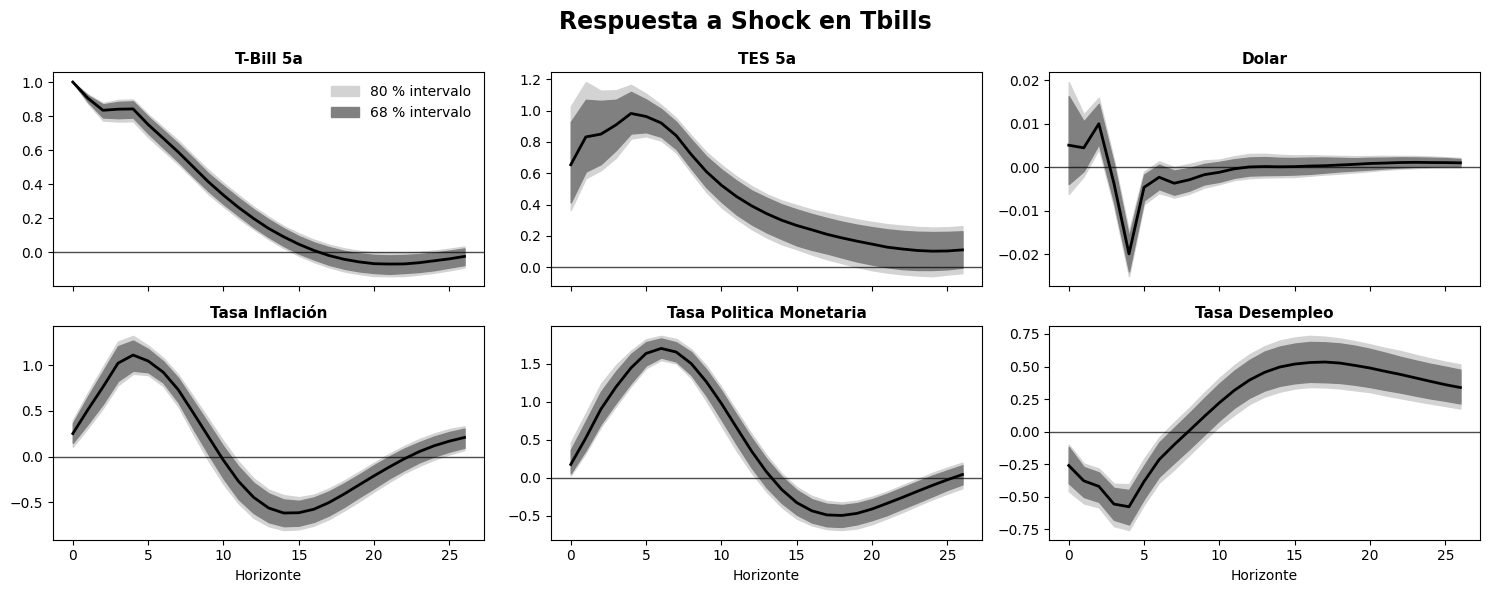

In [44]:
t = q50.shape[0]               # = HOR+1
x = np.arange(0, t)            # incluye 0
var_names = ["T-Bill 5a", "TES 5a", "Dolar", "Tasa Inflación", "Tasa Politica Monetaria", "Tasa Desempleo"]

ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=True)
fig.suptitle('Respuesta a Shock en Tbills', fontsize=17, fontweight='bold', y=0.98)
axes = np.atleast_2d(axes)

for j in range(n):  # por variable respuesta
    row, col = divmod(j, ncols)
    ax = axes[row, col]

    y     = q50[:, j, 0]   # respuesta de var j a shock Tbills (columna 0)
    low90 = q10[:, j, 0]
    up90  = q90[:, j, 0]
    low84 = q16[:, j, 0]
    up84  = q84[:, j, 0]

    ax.fill_between(x, low90, up90, color='lightgray', label='80 % intervalo' if j==0 else None)
    ax.fill_between(x, low84, up84, color='gray',       label='68 % intervalo' if j==0 else None)
    ax.plot(x, y, color='black', linewidth=2)

    ax.axhline(0, color='k', lw=1, alpha=0.7)
    ax.set_title(var_names[j], fontsize=11, fontweight='bold')

for k in range(n, nrows*ncols):
    r, c = divmod(k, ncols)
    axes[r, c].set_visible(False)

for c in range(ncols):
    axes[-1, c].set_xlabel("Horizonte")

axes[0, 0].legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

# FEVD

In [45]:
m_MCIRF = np.mean(MCIF, axis=0)


s= HOR+1
Ms = np.zeros((n , n*s))
Fs = np.zeros((n , n*s))
Ws = np.zeros((n , n*s))

def FEVD(IR , n , s):
    """
    Compute the Forecast Error Variance Decomposition (FEVD) from IRF matrices.

    Given the impulse response function (IR) array for a single Monte Carlo draw,
    this function calculates, for each horizon up to s-1, the proportion of the
    h-step ahead forecast error variance of each variable that is attributable
    to shocks in each variable.

    Returns
    -------
    Ws : ndarray, shape (n, n*s)
        FEVD proportions. For each horizon j (0 ≤ j < s), the block
        Ws[:, j*n:(j+1)*n] contains an n×n matrix where entry (i, k)
        is the fraction of variable i’s forecast error variance at
        horizon j explained by a unit shock to variable k.
    """

    Ms = np.zeros((n , n*s))
    Fs = np.zeros((n , n*s))
    Ws = np.zeros((n , n*s))

    Mss = (IR[0:n , 0:n]) * (IR[0:n , 0:n])
    Fss = (IR[0:n , 0:n]) @ (IR[0:n , 0:n]).T * np.eye(n)

    for j in range(1 , s-1):
        Mss = Mss + (IR[0:n , j*n:(j+1)*n]) * IR[0:n , j*n:(j+1)*n]
        Ms[:,j*n:(j+1)*n] = Mss
        Fss = Fss + (IR[0:n,j * n:(j+1) * n]) @ (IR[0:n,j * n:(j+1) * n]).T * np.eye(n)
        Fs[:,j * n:(j + 1) * n] = Fss
        Ws[:,j * n:(j + 1) * n] = np.linalg.solve(Fss, Mss)
    return Ws

ws = FEVD(m_MCIRF , n, s+1)
l= np.delete(ws[0, 0::n] + ws[0, 1::n], -1)
cs = np.delete(ws[0, 0::n] + ws[0, 1::n], -1)
u = -cs + 1

l1=np.delete(ws[1, 0::n] + ws[1, 1::n], -1)
cs1 = np.delete(ws[1, 0::n] + ws[1, 1::n], -1)
u1 = -cs1 + 1

l2=np.delete(ws[2, 1::n] + ws[2, 2::n], -1)
cs2 = np.delete(ws[2, 1::n] + ws[2, 2::n], -1)
u2 = -cs2 + 1


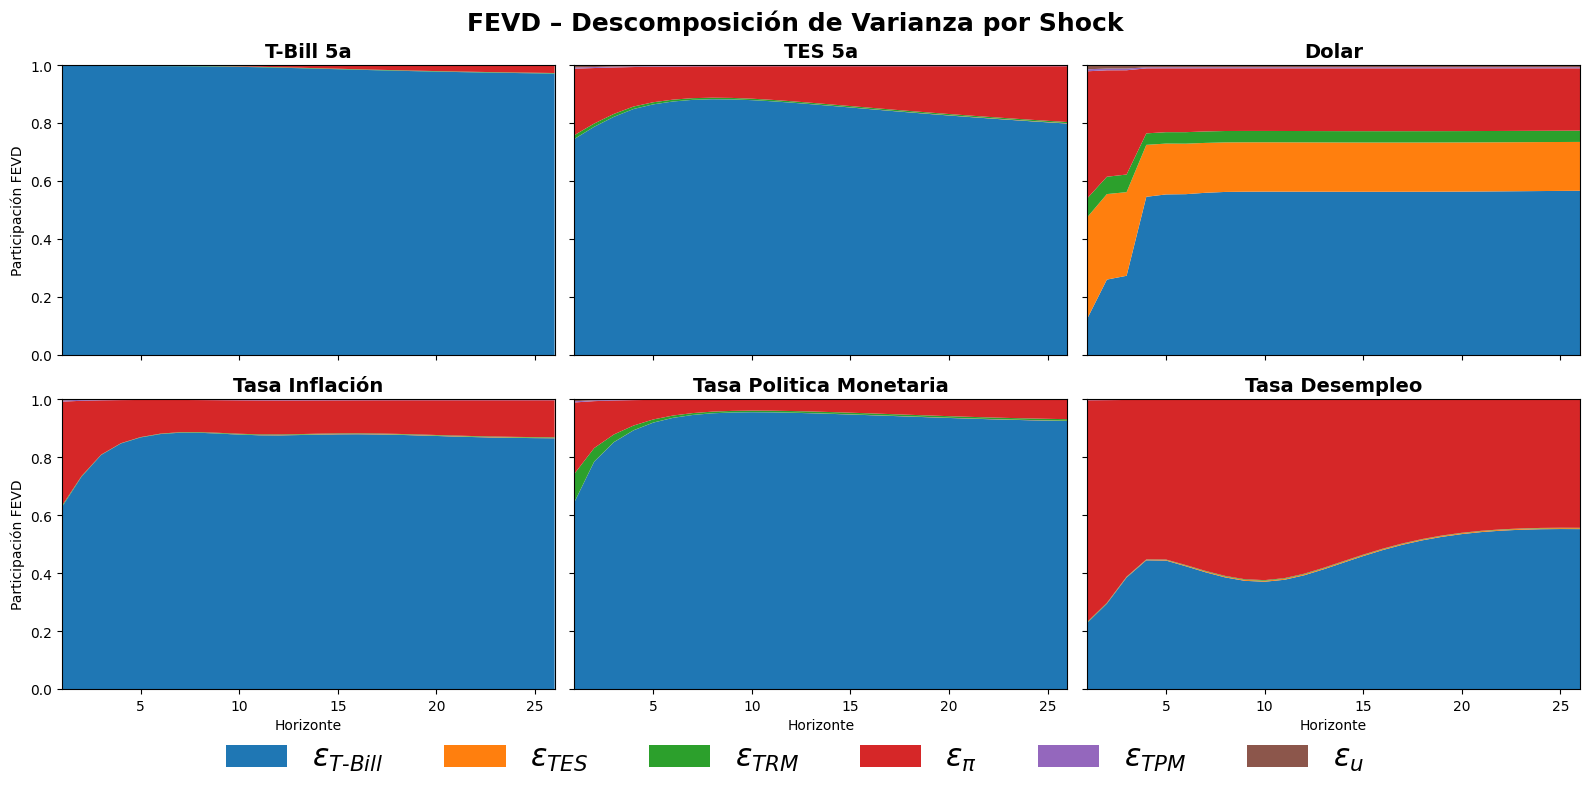

In [46]:
from matplotlib.patches import Patch

n = 6                           
s = ws.shape[1] // n             
horiz_full = np.arange(s)        
horiz = horiz_full[1:-1]           

fevd = ws.reshape(n, s, n)        
fevd_cut = fevd[:, 1:-1, :]      

# Names 
var_names   = ["T-Bill 5a", "TES 5a", "Dolar", "Tasa Inflación", "Tasa Politica Monetaria", "Tasa Desempleo"]
shock_names = [r"$\varepsilon_{T\text{-}Bill}$",r"$\varepsilon_{TES}$",r"$\varepsilon_{TRM}$",r"$\varepsilon_{\pi}$",
    r"$\varepsilon_{TPM}$",r"$\varepsilon_{u}$",]

cmap = plt.get_cmap("tab20")
colors = cmap([0,2,4,6,8,10])    

fig, axes = plt.subplots(2,3,figsize=(16,8),sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes[:n]):
    data = fevd_cut[i].T          # (n_shocks, s-2)
    ax.stackplot(horiz, *data, colors=colors, linewidth=0)
    ax.set_title(var_names[i], fontsize=14, weight='semibold')
    ax.set_xlim(horiz[0], horiz[-1])
    ax.set_ylim(0,1)
    ax.tick_params(labelsize=10)
    if i%3==0:   ax.set_ylabel("Participación FEVD")
    if i>=3:     ax.set_xlabel("Horizonte")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

legend_handles = [Patch(facecolor=colors[k]) for k in range(n)]
fig.legend(legend_handles,shock_names,loc='lower center',ncol=6,
    frameon=False,fontsize=22,bbox_to_anchor=(0.5, -0.02))

fig.suptitle("FEVD – Descomposición de Varianza por Shock",
             fontsize=18, weight='bold', y=0.97)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.90)
plt.show()

## Local Projectios (Jorda)

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def make_lags(df: pd.DataFrame, L: int):
    cols = {}
    for c in df.columns:
        for l in range(1, L+1):
            cols[f"{c}_L{l}"] = df[c].shift(l)
    return pd.DataFrame(cols, index=df.index)

def align_for_horizon(y: pd.Series, shock: pd.Series, X: pd.DataFrame, h: int, cumulative: bool=False):
    y_dep = (y.shift(-h) - y.shift(-1)) if cumulative else y.shift(-h)
    df = pd.concat([y_dep, shock, X], axis=1).dropna()
    return df.iloc[:,0], df.iloc[:,1], df.iloc[:,2:]


def lp_irf_single(y, shock, X_controls, H=20, hac=True):
    out = []
    for h in range(H+1):
        y_h, s_t, X_t = align_for_horizon(y, shock, X_controls, h, cumulative=False)
        Xreg = sm.add_constant(pd.concat([s_t.rename('shock'), X_t], axis=1))
        res = sm.OLS(y_h, Xreg).fit(cov_type='HAC', cov_kwds={'maxlags': max(h+1,1)}) if hac else sm.OLS(y_h, Xreg).fit()
        out.append(res.params['shock'])
    return np.asarray(out) 


def lp_betas_from_draws(
    order,
    H,
    p_lags,
    datos_var,      # dataframe fuente (para index)
    YY,             # panel usado en el VAR (T x n) ya transformado como en el VAR
    X, Y,           # matrices del VAR para yhat y residuales
    Posterior_B_MCMC,           # (R, k, n)
    Posterior_A0_MCMC,          # (q_params, R)  ó (n*n, R) según tu A0_Mtx
    A0_Mtx,                      # callable: A0_Mtx(theta_r) -> (n x n)
    include_shock_lags=False,
    shock_var_name='tbills',
    R_cap=2000,
    hac=True,
    normalize_shock='sd'         # None | 'sd'
):
    """
    Corre LP para cada draw del SBVAR y devuelve:
      - betas_lp: dict[var] -> list of arrays (R_used elementos, cada uno (H+1,))
      - idx_eff, R_used
    """
    n = len(order)
    df_q = datos_var.copy()
    df_lp = pd.DataFrame(YY, index=df_q.index[:len(YY)], columns=order)

    T_eff = X.shape[0]
    df_lp_eff = df_lp.iloc[-T_eff:].copy()
    idx_eff = df_lp_eff.index

    R_total = Posterior_B_MCMC.shape[0]
    R_used = min(R_cap, R_total)

    IDX_SHOCK = order.index(shock_var_name)
    betas_lp = {y: [] for y in order}

    # preconstruye controles sin shock (comparables con VAR)
    from pandas import concat
    def make_controls(base_df, p):
        return make_lags(base_df, p)

    for r in range(R_used):
        B_r  = Posterior_B_MCMC[r, :, :]
        yhat = X @ B_r
        Y_eff = Y[-T_eff:, :]
        u_r   = Y_eff - yhat

        A0_r  = A0_Mtx(Posterior_A0_MCMC[:, r])
        e_r   = (A0_r @ u_r.T).T

        # serie del shock estructural
        shock_r = pd.Series(e_r[:, IDX_SHOCK], index=idx_eff, name='shock_struct')

        # normalización (importante para comparar con IRF del SBVAR por 1 s.d.)
        if normalize_shock == 'sd':
            sd = shock_r.std(ddof=1)
            if sd > 0:
                shock_r = shock_r / sd

        if include_shock_lags:
            tmp = df_lp_eff.copy()
            tmp['shock_struct'] = shock_r
            X_controls = make_controls(tmp[order + ['shock_struct']], p_lags)
        else:
            X_controls = make_controls(df_lp_eff[order], p_lags)

        # LP por variable objetivo
        for yname in order:
            b_vec = lp_irf_single(df_lp_eff[yname], shock_r, X_controls, H=H, hac=hac)
            betas_lp[yname].append(b_vec)

    return betas_lp, idx_eff, R_used

order = ['tbills','tes','dlog_trm','inflacion','tpm','desempleo_sa']
titles = {
    'tbills':        'T-Bill 5a',
    'tes':           'TES 5a',
    'dlog_trm':      'Dólar',
    'inflacion':     'Tasa Inflación',
    'tpm':           'Tasa Politica Monetaria',
    'desempleo_sa':  'Tasa Desempleo',}

betas_lp, idx_eff, R_used = lp_betas_from_draws(
    order=order, H=HOR, p_lags=m,
    datos_var=datos_var, YY=YY, X=X, Y=Y,
    Posterior_B_MCMC=Posterior_B_MCMC,
    Posterior_A0_MCMC=Posterior_A0_MCMC,
    A0_Mtx=A0_Mtx,
    include_shock_lags=False,
    shock_var_name='tbills',
    R_cap=2000,
    hac=True,
    normalize_shock='sd')


## Graph IRFs from LP

In [ ]:
from scipy.signal import savgol_filter

def _odd_leq(n):
    return n if n % 2 == 1 else n-1

def _choose_window(H, base=7):
    # ventana impar, al menos 3 y <= H-1
    w = max(3, base)
    w = _odd_leq(min(w, H-1))
    if w < 3: w = 3
    if w >= H: w = _odd_leq(H-1)
    return w

def smooth_1d(y, method="savgol", window=None, polyorder=2):
    y = np.asarray(y, float)
    H = y.size
    if H < 5:
        return y.copy()
    if method == "savgol":
        w = _choose_window(H, base=(window or 7))
        poly = min(polyorder, w-1)  # debe ser < window
        ys = savgol_filter(y, window_length=w, polyorder=poly, mode="interp")
        ys[0] = y[0]                 # fijar h=0
        return ys
    elif method == "ma":
        w = window or 5
        w = max(3, w)
        if w > H: w = H
        k = w//2
        pad = (k, w-1-k)
        ypad = np.pad(y, pad, mode="edge")
        c = np.convolve(ypad, np.ones(w)/w, mode="valid")
        c[0] = y[0]
        return c
    else:
        return y.copy()

def smooth_band(lo, med, up, **kwargs):
    lo_s  = smooth_1d(lo,  **kwargs)
    med_s = smooth_1d(med, **kwargs)
    up_s  = smooth_1d(up,  **kwargs)
    # Asegurar orden de bandas
    lo_s  = np.minimum.reduce([lo_s, med_s, up_s])
    up_s  = np.maximum.reduce([lo_s, med_s, up_s])
    med_s = np.clip(med_s, lo_s, up_s)
    return lo_s, med_s, up_s


def _stack_draws(draw_list):
    """Convierte lista de vectores (H+1,) a matriz (R, H+1) sin recalcular nada."""
    A = np.asarray(draw_list)
    if A.ndim == 1:     
        A = A[None, :]
    if A.ndim == 2:
        return A
    return np.vstack(draw_list)

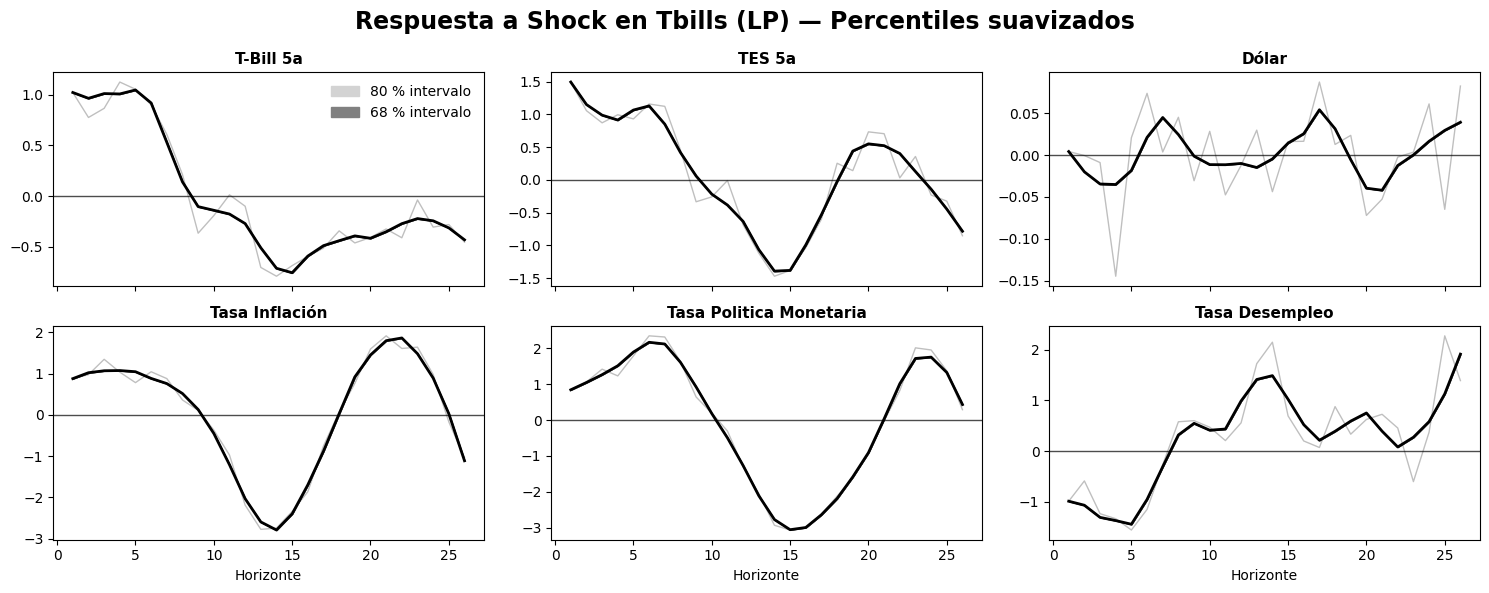

In [ ]:



def lp_bands_from_betas(betas_lp, order, H):
    """
    Devuelve:
      - bands_68: dict[var] -> DataFrame(h, p16, p50, p84)
      - bands_80: dict[var] -> dict(p10, p90 arrays)
    """
    bands_68 = {}
    bands_80 = {}
    for var in order:
        B = _stack_draws(betas_lp[var])        # (R_used, H+1)
        H_eff = min(H+1, B.shape[1])
        B = B[:, :H_eff]
        h = np.arange(H_eff)
        bands_68[var] = pd.DataFrame({
            'h':   h,
            'p16': np.percentile(B, 16, axis=0),
            'p50': np.percentile(B, 50, axis=0),
            'p84': np.percentile(B, 84, axis=0),
        })
        bands_80[var] = {
            'p10': np.percentile(B, 10, axis=0),
            'p90': np.percentile(B, 90, axis=0)}
        
    return bands_68, bands_80

def lp_prepare_plot_mats(bands_68, bands_80, order, H):
    n = len(order)
    q10 = np.zeros((H, n))
    q16 = np.zeros((H, n))
    q50 = np.zeros((H, n))
    q84 = np.zeros((H, n))
    q90 = np.zeros((H, n))

    for j, var in enumerate(order):
        dfq = bands_68[var]
        mask = (dfq['h'].values >= 1) & (dfq['h'].values <= H)
        q16[:, j] = dfq.loc[mask, 'p16'].to_numpy()
        q50[:, j] = dfq.loc[mask, 'p50'].to_numpy()
        q84[:, j] = dfq.loc[mask, 'p84'].to_numpy()
        q10[:, j] = bands_80[var]['p10'][1:H+1]
        q90[:, j] = bands_80[var]['p90'][1:H+1]
    return q10, q16, q50, q84, q90

def plot_lp_percentiles(
    q10, q16, q50, q84, q90, order, titles=None,
    figsize_base=(5, 3), ncols=3, title='Respuesta a Shock en Tbills (LP) — Percentiles',
    smooth=True, smooth_method='savgol', smooth_window=7, smooth_polyorder=2,
    show_original_center=False, savepath=None):
    """
    Grafica bandas 68% y 80% con mediana. Suavizado opcional para visualización.
    """
    n = len(order)
    t = q50.shape[0]
    x = np.arange(1, t+1)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(figsize_base[0]*ncols, figsize_base[1]*nrows),
                             sharex=True)
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=17, fontweight='bold', y=0.98)

    for j, var in enumerate(order):
        r, c = divmod(j, ncols)
        ax = axes[r, c]
        if smooth:
            lo80_s, med_s, up80_s = smooth_band(q10[:, j], q50[:, j], q90[:, j],
                                                 method=smooth_method, window=smooth_window,
                                                 polyorder=smooth_polyorder)
            lo68_s, _,     up68_s = smooth_band(q16[:, j], q50[:, j], q84[:, j],
                                                 method=smooth_method, window=smooth_window,
                                                 polyorder=smooth_polyorder)
        else:
            lo80_s, med_s, up80_s = q10[:, j], q50[:, j], q90[:, j]
            lo68_s, up68_s        = q16[:, j], q84[:, j]

        if show_original_center and smooth:
            ax.plot(x, q50[:, j], color='black', alpha=0.25, linewidth=1)

        ax.fill_between(x, lo80_s, up80_s, color='lightgray', label='80 % intervalo' if j==0 else None)
        ax.fill_between(x, lo68_s, up68_s, color='gray',       label='68 % intervalo' if j==0 else None)
        ax.plot(x, med_s, color='black', linewidth=2)

        ax.axhline(0, color='k', lw=1, alpha=0.7)
        ttl = (titles or {}).get(var, var)
        ax.set_title(ttl, fontsize=11, fontweight='bold')

    # ocultar subplots vacíos
    for k in range(n, nrows*ncols):
        rr, cc = divmod(k, ncols)
        axes[rr, cc].set_visible(False)
    for cc in range(ncols):
        axes[-1, cc].set_xlabel("Horizonte")

    axes[0, 0].legend(loc="upper right", frameon=False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches='tight')
    plt.show()

    return fig

bands_68, bands_80 = lp_bands_from_betas(betas_lp, order=order, H=HOR)
q10_lp, q16_lp, q50_lp, q84_lp, q90_lp = lp_prepare_plot_mats(bands_68, bands_80, order=order, H=HOR)

_ = plot_lp_percentiles(
    q10=q10_lp, q16=q16_lp, q50=q50_lp, q84=q84_lp, q90=q90_lp,
    order=order, titles=titles,
    title='Respuesta a Shock en Tbills (LP) — Percentiles suavizados',
    smooth=True, smooth_method='savgol', smooth_window=7, smooth_polyorder=2,
    show_original_center=True,
    savepath=None)

## Local Projections Using (HAC)

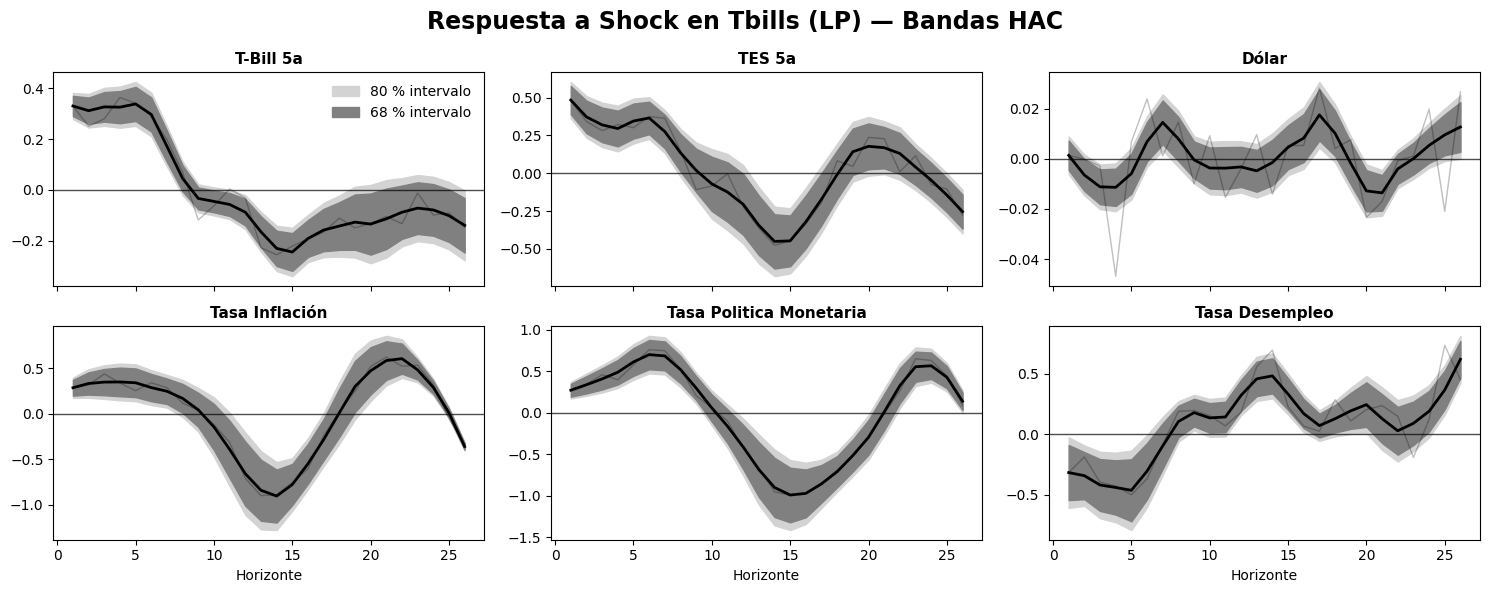

In [ ]:
def lp_hac_from_ref_draw(
    order,
    H,
    p_lags,
    datos_var,      # df fuente solo para index
    YY,             # panel VAR (T x n) ya transformado
    X, Y,           # matrices del VAR (para residuales)
    Posterior_B_MCMC,          # (R,k,n)
    Posterior_A0_MCMC,         # (q_params, R)
    A0_Mtx,                     # callable: A0_Mtx(theta_r)->(n x n)
    r_ref=0,
    shock_var_name='tbills',
    include_shock_lags=False,
    normalize_shock='sd',       # None | 'sd' (1 s.d.)
    z68=1.0,
    z80=1.28155):

    """
    Devuelve:
      - betas: dict[var] -> array (H+1,)
      - ses:   dict[var] -> array (H+1,)
      - q50, lo68, up68, lo80, up80: matrices (H x n) listas para graficar (h=1..H).
    Requiere make_lags(...) y lp_irf_single_beta_se(...).
    """
    n = len(order)
    IDX_SHOCK = order.index(shock_var_name)

    # datos alineados con el VAR
    df_q  = datos_var.copy()
    df_lp = pd.DataFrame(YY, index=df_q.index[:len(YY)], columns=order)
    T_eff = X.shape[0]
    df_lp_eff = df_lp.iloc[-T_eff:].copy()
    idx_eff = df_lp_eff.index

    # draw de referencia
    B_ref  = Posterior_B_MCMC[r_ref, :, :]
    yhat   = X @ B_ref
    Y_eff  = Y[-T_eff:, :]
    u_ref  = Y_eff - yhat

    A0_ref = A0_Mtx(Posterior_A0_MCMC[:, r_ref])
    e_ref  = (A0_ref @ u_ref.T).T                         # (T_eff x n)

    shock_ref = pd.Series(e_ref[:, IDX_SHOCK], index=idx_eff, name='shock_tbills')
    if normalize_shock == 'sd':
        sd = shock_ref.std(ddof=1)
        if sd > 0:
            shock_ref = shock_ref / sd

    # controles LP (comparables con VAR)
    if include_shock_lags:
        tmp = df_lp_eff.copy()
        tmp['shock_tbills'] = shock_ref
        X_controls = make_lags(tmp[order + ['shock_tbills']], p_lags)
    else:
        X_controls = make_lags(df_lp_eff[order], p_lags)

    # β y SE por variable/horizonte
    betas, ses = {}, {}
    for var in order:
        b, s = lp_irf_single_beta_se(df_lp_eff[var], shock_ref, X_controls, H=H)
        betas[var] = b
        ses[var]   = s

    # construir matrices (H x n), descartando h=0 para el plot
    q50 = np.zeros((H, n))
    lo68 = np.zeros((H, n)); up68 = np.zeros((H, n))
    lo80 = np.zeros((H, n)); up80 = np.zeros((H, n))

    for j, var in enumerate(order):
        b = betas[var][1:H+1]
        s = ses[var][1:H+1]
        q50[:, j]  = b
        lo68[:, j] = b - z68*s;  up68[:, j] = b + z68*s
        lo80[:, j] = b - z80*s;  up80[:, j] = b + z80*s

    return betas, ses, q50, lo68, up68, lo80, up80

def plot_lp_hac(
    q50, lo68, up68, lo80, up80,
    order, titles=None,
    ncols=3, figsize_base=(5,3),
    title='Respuesta a Shock en Tbills (LP) — Bandas HAC',
    smooth=True, smooth_method='savgol', smooth_window=7, smooth_polyorder=2,
    show_original_center=False,
    savepath=None):
    
    """
    Grafica bandas 68%/80% (H x n) y la mediana q50 (H x n).
    """
    n = len(order)
    t = q50.shape[0]
    x = np.arange(1, t+1)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(figsize_base[0]*ncols, figsize_base[1]*nrows),
                             sharex=True)
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=17, fontweight='bold', y=0.98)

    for j, var in enumerate(order):
        r, c = divmod(j, ncols)
        ax = axes[r, c]

        if smooth:
            lo80_s, med_s, up80_s = smooth_band(lo80[:, j], q50[:, j], up80[:, j],
                                                 method=smooth_method, window=smooth_window,
                                                 polyorder=smooth_polyorder)
            lo68_s, _,     up68_s = smooth_band(lo68[:, j], q50[:, j], up68[:, j],
                                                 method=smooth_method, window=smooth_window,
                                                 polyorder=smooth_polyorder)
        else:
            lo80_s, med_s, up80_s = lo80[:, j], q50[:, j], up80[:, j]
            lo68_s, up68_s        = lo68[:, j], up68[:, j]

        if show_original_center and smooth:
            ax.plot(x, q50[:, j], color='black', alpha=0.25, linewidth=1)

        ax.fill_between(x, lo80_s, up80_s, color='lightgray', label='80 % intervalo' if j==0 else None)
        ax.fill_between(x, lo68_s, up68_s, color='gray',       label='68 % intervalo' if j==0 else None)
        ax.plot(x, med_s, color='black', linewidth=2)

        ax.axhline(0, color='k', lw=1, alpha=0.7)
        ttl = (titles or {}).get(var, var)
        ax.set_title(ttl, fontsize=11, fontweight='bold')

    # ocultar celdas vacías + ejes
    for k in range(n, nrows*ncols):
        rr, cc = divmod(k, ncols)
        axes[rr, cc].set_visible(False)
    for cc in range(ncols):
        axes[-1, cc].set_xlabel("Horizonte")

    axes[0, 0].legend(loc="upper right", frameon=False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

order = ['tbills','tes','dlog_trm','inflacion','tpm','desempleo_sa']
titles = {'tbills':'T-Bill 5a','tes':'TES 5a','dlog_trm':'Dólar',
          'inflacion':'Tasa Inflación','tpm':'Tasa Politica Monetaria',
          'desempleo_sa':'Tasa Desempleo'}

betas, ses, q50, lo68, up68, lo80, up80 = lp_hac_from_ref_draw(
    order=order, H=HOR, p_lags=m,
    datos_var=datos_var, YY=YY, X=X, Y=Y,
    Posterior_B_MCMC=Posterior_B_MCMC,
    Posterior_A0_MCMC=Posterior_A0_MCMC,
    A0_Mtx=A0_Mtx,
    r_ref=0,                       
    shock_var_name='tbills',
    include_shock_lags=False,
    normalize_shock='sd')

_ = plot_lp_hac(
    q50=q50, lo68=lo68, up68=up68, lo80=lo80, up80=up80,
    order=order, titles=titles,
    title='Respuesta a Shock en Tbills (LP) — Bandas HAC',
    smooth=True, smooth_method='savgol', smooth_window=7, smooth_polyorder=2,
    show_original_center=True,
    savepath=None )


## Pablo Reyes 